In [1]:
# m2 task:
# practice by parsing elexon data from last 24h and combine relevant columns to form the 'matrix'


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option('display.max_rows', None)

# assign variable to store file path
# we have past week + past 10 year files. check filename to distinguish. no issues with loading the data
file_path = 'GenerationByFuelType-2016-01-01T00_00_00.000Z-2026-06-15T14_30_00.000Z.csv'

# reads a csv file into a DataFrame
# a DataFrame is a 2D array and used for larger data sets 
df = pd.read_csv(file_path)



In [7]:
# testing dataframe functions:

# prints first 5 rows by default (data appears formatted compared to printing it)
#print('First 5 Rows: \n')
#print(df.head(100))
#print('\n')


print('All Info about DataFrame: \n')
df.info()


All Info about DataFrame: 

<class 'pandas.DataFrame'>
RangeIndex: 3026972 entries, 0 to 3026971
Data columns (total 7 columns):
 #   Column            Dtype
---  ------            -----
 0   Dataset           str  
 1   PublishTime       str  
 2   StartTime         str  
 3   SettlementDate    str  
 4   SettlementPeriod  int64
 5   FuelType          str  
 6   Generation        int64
dtypes: int64(2), str(5)
memory usage: 161.7 MB


In [2]:
# m2 task continued: pivot the data (long to wide format) i.e choose index labels (listed along side), column labels (listed across top) and values to fill the table 

# clean column names of empty spaces
df.columns = df.columns.str.strip()

# apply pivot function
df_pivot = df.pivot_table(
    index = ['SettlementDate', 'SettlementPeriod'],
    columns = 'FuelType',
    values = 'Generation',
    aggfunc = sum
)

# turn row labels back into columns
df_pivot = df_pivot.reset_index()



In [9]:
# check the pivoted data

print('First 5 rows: \n')
print(df_pivot.head())
print('\n')

df_pivot.info()

First 5 rows: 

FuelType SettlementDate  SettlementPeriod  BIOMASS    CCGT    COAL  INTELE  \
0            2016-01-01                 1      NaN  5716.0  3434.0     NaN   
1            2016-01-01                 2      NaN  6670.0  3583.0     NaN   
2            2016-01-01                 3      NaN  6985.0  3865.0     NaN   
3            2016-01-01                 4      NaN  6839.0  3772.0     NaN   
4            2016-01-01                 5      NaN  6775.0  3555.0     NaN   

FuelType  INTELEC  INTEW   INTFR  INTGRNL  ...  INTNEM  INTNSL  INTVKL  \
0             NaN  104.0  1756.0      NaN  ...     NaN     NaN     NaN   
1             NaN   26.0  1756.0      NaN  ...     NaN     NaN     NaN   
2             NaN   36.0  1756.0      NaN  ...     NaN     NaN     NaN   
3             NaN   64.0  1756.0      NaN  ...     NaN     NaN     NaN   
4             NaN   20.0  1756.0      NaN  ...     NaN     NaN     NaN   

FuelType  NPSHYD  NUCLEAR  OCGT  OIL   OTHER     PS    WIND  
0       

In [3]:
# m2 task continued: combine relevant columns

# gas column
df_pivot ['Gas'] = df_pivot ['OCGT'] + df_pivot ['CCGT']


# interconnector column
int_columns = df_pivot.filter(like = 'INT') 
#print(int_columns)
df_pivot ['Int'] =  int_columns.sum(axis = 1) #axis=1 means add horizontally (for each row)


# hydroelectric column
df_pivot ['Hydro'] = df_pivot ['NPSHYD'] 

In [4]:
# m2 task continued: create the final matrix

# copy columns to the final dataframe
final_matrix_df = df_pivot[
    ['SettlementDate', 
    'SettlementPeriod', 
    'Gas', 
    'NUCLEAR', 
    'Int', 
    'BIOMASS', 
    'Hydro',
     'COAL',
     'OIL',
     'PS',
     'WIND',
    'OTHER']
].copy()

# rename columns
final_matrix_df = final_matrix_df.rename(columns={
    'SettlementDate': 'Date',
    'SettlementPeriod': 'Period',
    'NUCLEAR': 'Nuclear',
    'BIOMASS': 'Biomass',
    'OIL':'Oil',
    'COAL':'Coal',
    'PS':'Pump Storage',
    'WIND':'Wind',
    'OTHER': 'Other'
})


final_matrix_df = final_matrix_df.sort_values(by=['Date', 'Period']) #sort by date first and then period
print(final_matrix_df.head(48)) # for a day



FuelType        Date  Period      Gas  Nuclear     Int  Biomass   Hydro  \
0         2016-01-01       1   5716.0   8289.0  2756.0      NaN   710.0   
1         2016-01-01       2   6670.0   8292.0  2688.0      NaN   659.0   
2         2016-01-01       3   6985.0   8297.0  2742.0      NaN   643.0   
3         2016-01-01       4   6839.0   8285.0  2694.0      NaN   642.0   
4         2016-01-01       5   6775.0   8279.0  2554.0      NaN   642.0   
5         2016-01-01       6   6897.0   8276.0  2560.0      NaN   642.0   
6         2016-01-01       7   7340.0   8266.0  2452.0      NaN   665.0   
7         2016-01-01       8   6927.0   8254.0  2466.0      NaN   862.0   
8         2016-01-01       9   6510.0   8236.0  2468.0      NaN   934.0   
9         2016-01-01      10   6137.0   8230.0  2496.0      NaN   960.0   
10        2016-01-01      11   6038.0   8216.0  2558.0      NaN   960.0   
11        2016-01-01      12   5833.0   8216.0  2598.0      NaN   961.0   
12        2016-01-01     

Summer Day vs Winter Day:




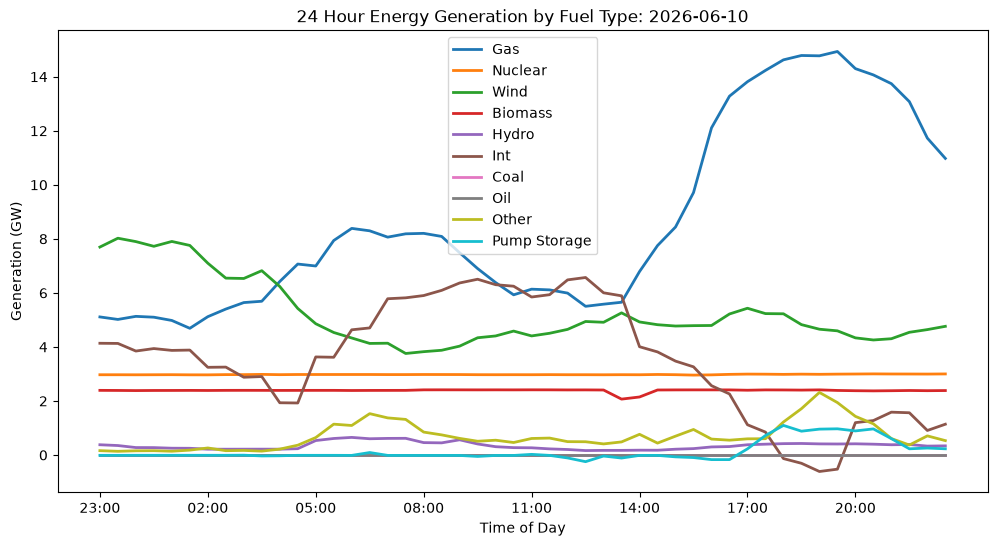

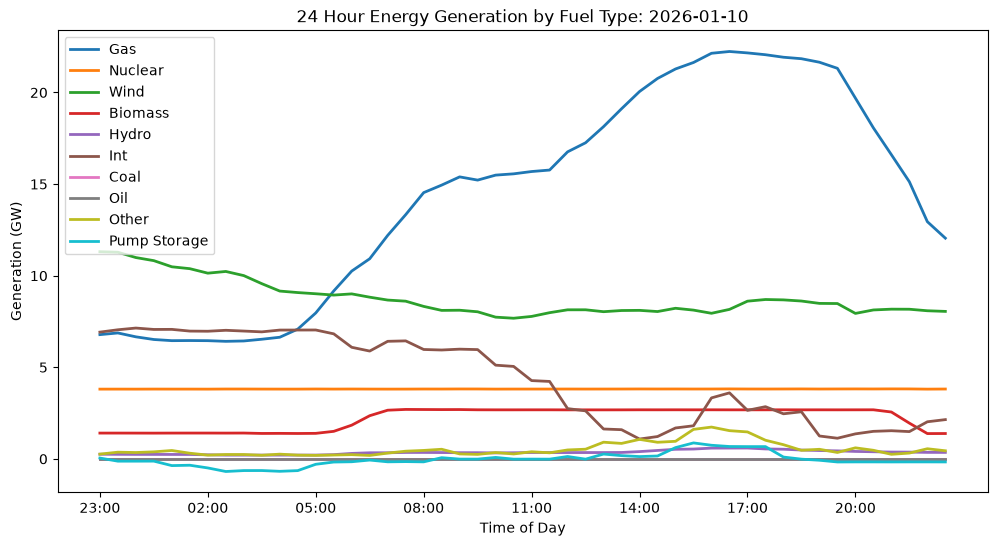







recent day vs old day:




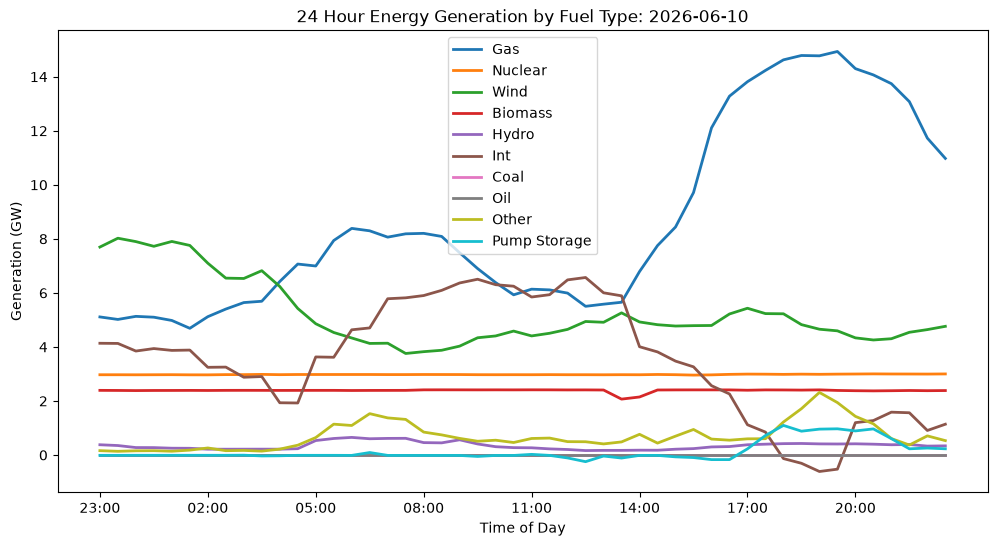

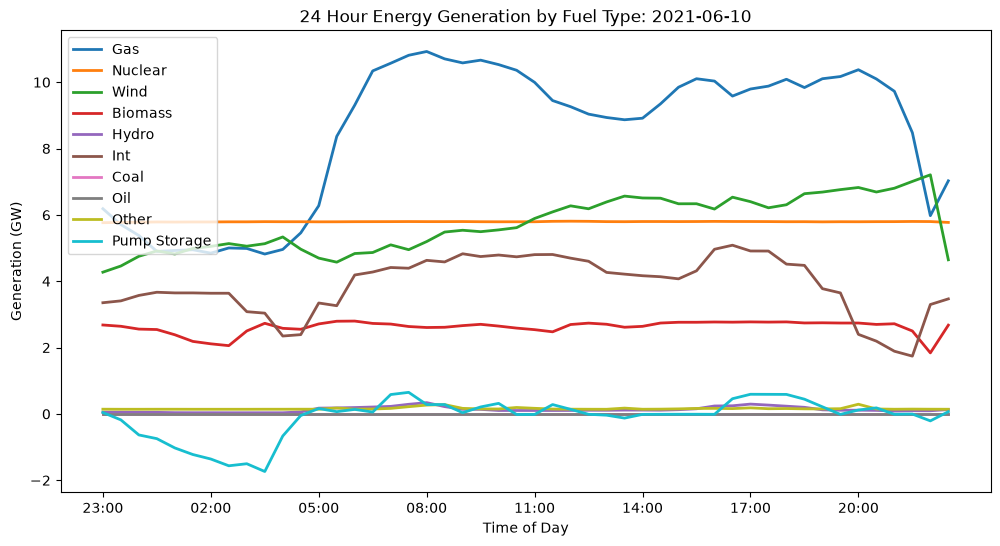

--------------------------------------------------------------------------


In [17]:
# m3: will plot elexon of a single 24 hr period   
    
def plot_some_day(date):  
    
    # select some day    
    day = date
    date_column = (final_matrix_df['Date']) # prints out the date_column in final matrix
    boolean_date_col  = date_column == day # returns boolean values in place of column
    #print(boolean_date_col.head())
    
    one_day = final_matrix_df[boolean_date_col].copy() # final matrix but only the rows for that day
    #print(one_day.head())
    
    # hard code times
    time_labels = [
        '23:00', '23:30', '00:00', '00:30', '01:00', '01:30', '02:00', '02:30', 
        '03:00', '03:30', '04:00', '04:30', '05:00', '05:30', '06:00', '06:30', 
        '07:00', '07:30', '08:00', '08:30', '09:00', '09:30', '10:00', '10:30', 
        '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', 
        '15:00', '15:30', '16:00', '16:30', '17:00', '17:30', '18:00', '18:30', 
        '19:00', '19:30', '20:00', '20:30', '21:00', '21:30', '22:00', '22:30']
    
    # sort so that 23:00 matches 1 
    one_day = one_day.sort_values('Period') # sorts ascending by default
    
    # create a new column
    one_day ['Time'] = time_labels
    #print('With time column: \n')
    #print(one_day.head())
    
    # so that plot is big enough
    plt.figure(figsize=(12, 6))
    
    
    fuels_to_plot = ['Gas', 'Nuclear', 'Wind',  'Biomass', 'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage']
    
    for fuel in fuels_to_plot:
        x_values = one_day['Time'] # acess values in time column
        y_values = one_day[fuel] / 1000  # access values in the fueltype + convert to GW
        plt.plot(x_values, y_values, label=fuel, linewidth=2) # draw a line
    
    
    # generate plots
    plt.title(f'24 Hour Energy Generation by Fuel Type: {day}')
    plt.ylabel('Generation (GW)')
    plt.xlabel('Time of Day')
    plt.xticks(ticks = range (0, 48, 6)) # show certain time column values
    plt.yticks()
    plt.legend()
    plt.show()


# choose some day 
print('Summer Day vs Winter Day:')
print('\n')

summer_day = '2026-06-10'
winter_day = '2026-01-10'

plot_some_day(summer_day)
print('\n')

plot_some_day(winter_day)
print('\n\n\n\n\n')


print('recent day vs old day:')
print('\n')

new_day = '2026-06-10'
old_day = '2021-06-10'

plot_some_day(new_day)
print('\n')

plot_some_day(old_day)


print('--------------------------------------------------------------------------')


Summer Week vs Winter Week:
---------------------------


Summer:


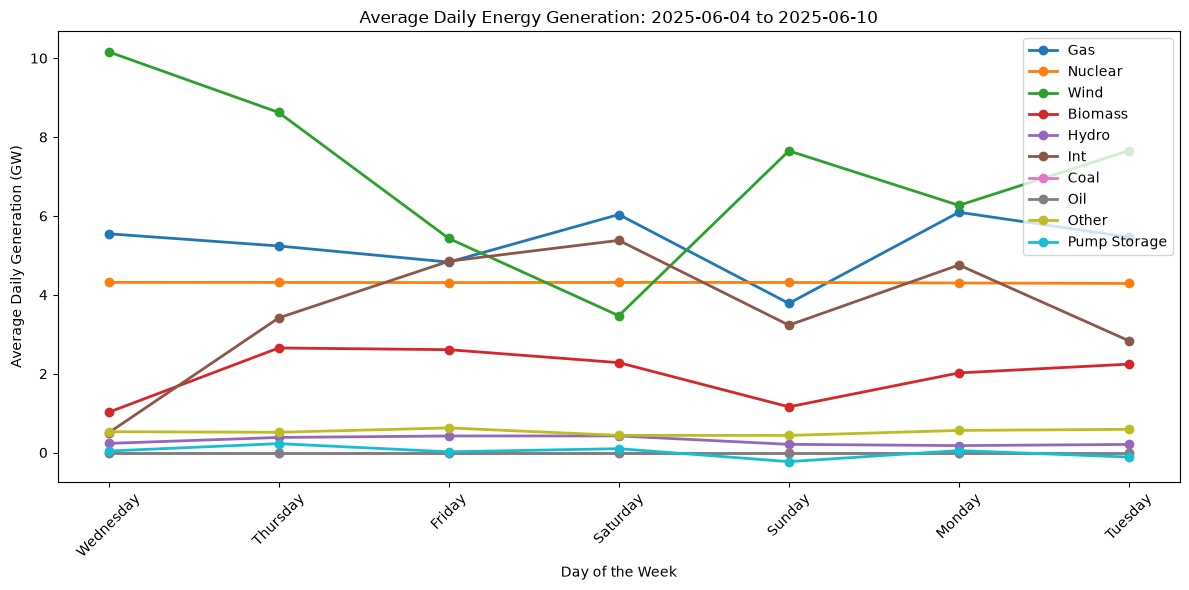


 
 
Winter:


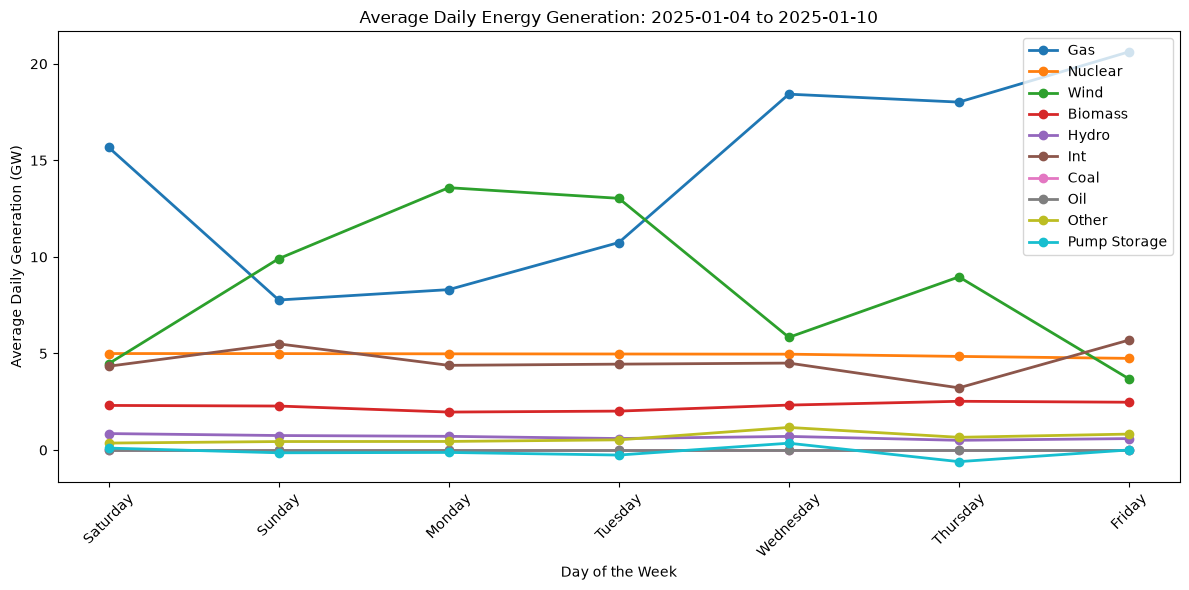


 
 

 
 
Recent Week vs Old Week (Summer Vs Winter):
-------------------------------------------


Recent:


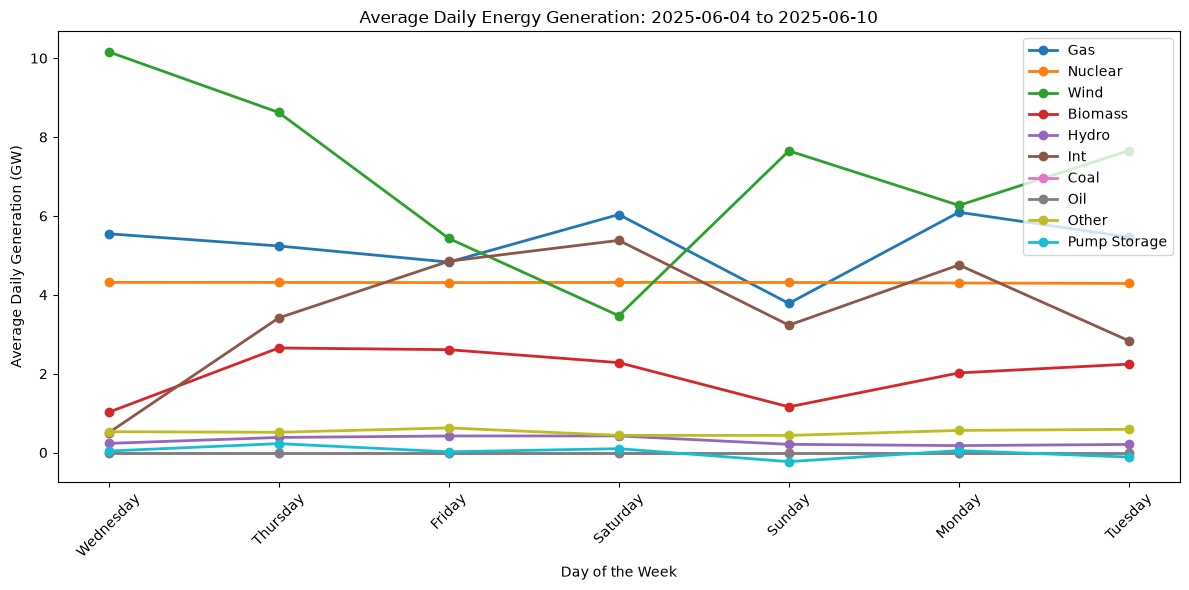


 
 
Old:


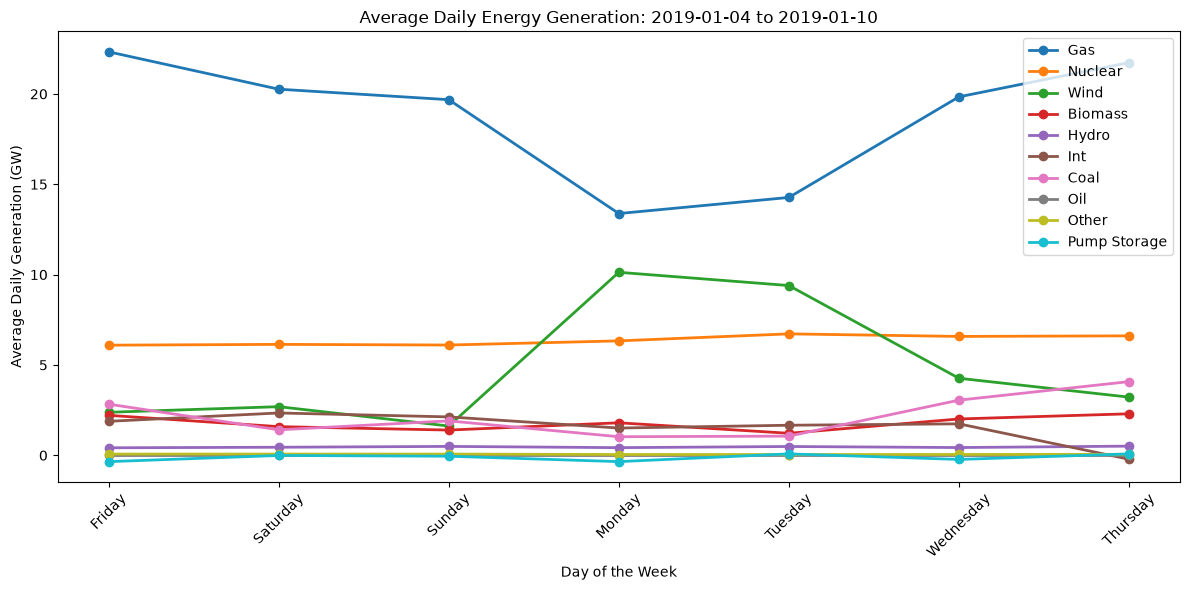

In [18]:
# m4: will plot elexon of a single week


#print(final_matrix_df.head(48)) # for a day, will need to average all values meaning there will be only one value over 48 settlement period


def plot_week_average(start_date, end_date):  
    
    #print(f'Averaging data from {start_date} to {end_date}')
    date_column = final_matrix_df['Date'] 
    
    # returns boolean column
    boolean_date_col = (date_column >= start_date) & (date_column <= end_date)
    
    week_data = final_matrix_df[boolean_date_col].copy() # final matrix but only the rows for that week
    #print (week_data.head(500)) # 7 * 48 rows predicted
    #print (f'Found {len(week_data)} rows of data in this range.') # matches !

    
    
    # convert the date column to pandas datetime objects so it can be manipulated later
    #print (week_data['Date'])
    week_data['Date'] = pd.to_datetime(week_data['Date'])
    #print (week_data['Date'])


    daily_average = week_data.groupby('Date').mean(numeric_only=True).reset_index() # don't need sqaure brackets to index
    
    # looks at the pandas datetime object and returns the name of day
    daily_average['DayOfWeek'] = daily_average['Date'].dt.day_name()
    #print (daily_average.head())
    
    # sord days in chron order from mon to sun
    daily_average = daily_average.sort_values('Date')
    
    #print(daily_average[['Date','DayOfWeek', Gas','Nuclear', Wind']] .head())
    
    # so that plot is big enough
    plt.figure(figsize=(12, 6))
    
    fuels_to_plot = ['Gas', 'Nuclear', 'Wind', 'Biomass', 'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage']
    
    for fuel in fuels_to_plot:
        x_values = daily_average['DayOfWeek'] # 
        y_values = daily_average[fuel] / 1000  # access values in the fueltype + convert to GW
        
        plt.plot(x_values, y_values, label=fuel, linewidth=2, marker='o') # draw a line with dots
    
    # generate plots
    plt.title(f'Average Daily Energy Generation: {start_date} to {end_date}')
    plt.ylabel('Average Daily Generation (GW)')
    plt.xlabel('Day of the Week')

    
    plt.xticks(rotation=45)
    plt.yticks()
    plt.legend()
    plt.tight_layout() # ensures the tilted text doesn't get cut off at bottom
    plt.show()



print('summer week vs winter week: ')
print('---------------------------')
print('\n')

summer_week_start = '2025-06-04'
summer_week_end = '2025-06-10'

winter_week_start = '2025-01-04'
winter_week_end = '2025-01-10'

print (f'Summer:')
plot_week_average(summer_week_start, summer_week_end)
print('\n \n ')

print (f'Winter:')
plot_week_average(winter_week_start, winter_week_end)
print('\n \n ')
print('\n \n ')


#-----------------------------------------------------


print('Recent Week vs Old Week (Summer Vs Winter):')
print('-------------------------------------------')
print('\n')

recent_week_start = '2025-06-04'
recent_week_end = '2025-06-10'

old_week_start = '2019-01-04'
old_week_end = '2019-01-10'

print (f'Recent:')
plot_week_average(recent_week_start, recent_week_end)
print('\n \n ')

print (f'Old:')
plot_week_average(old_week_start, old_week_end)






Yearly Monthly Average:
-----------------------




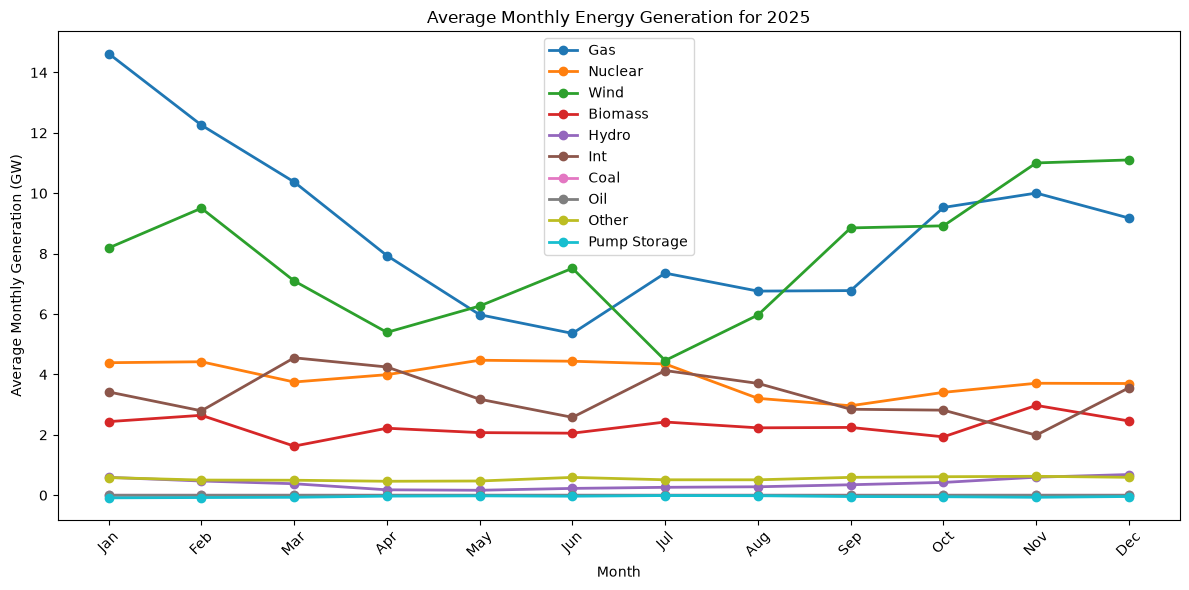

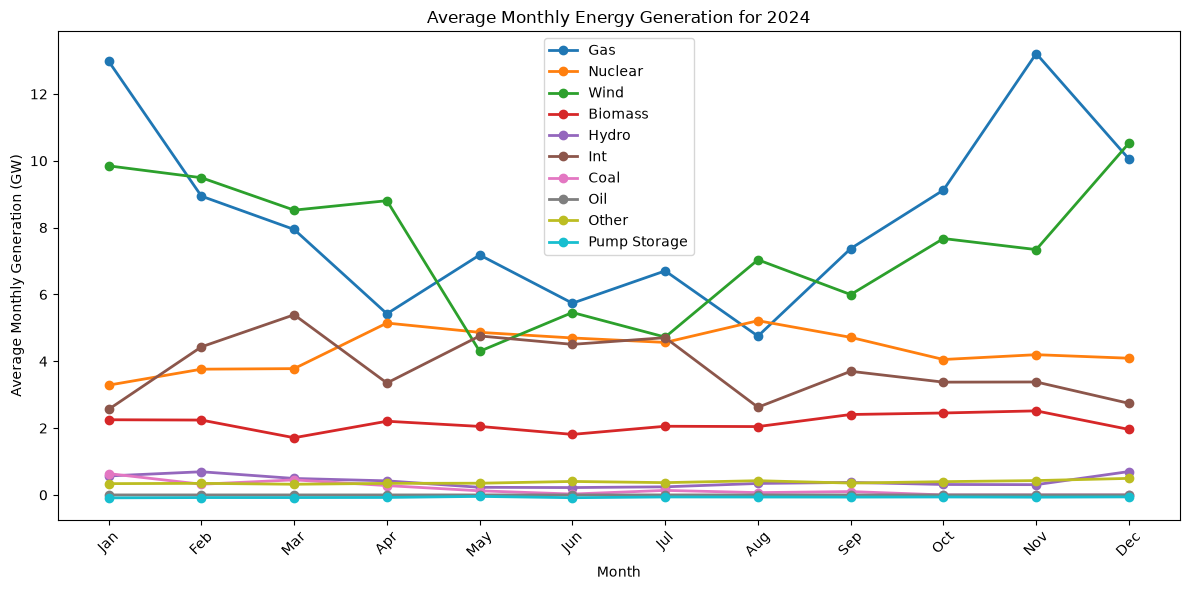

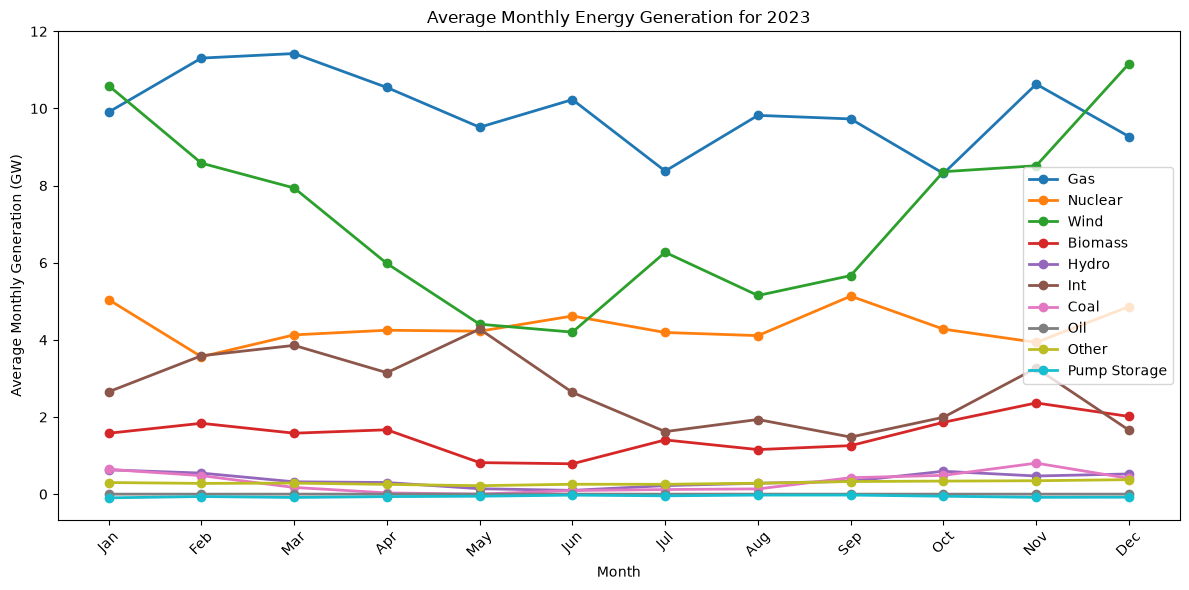

In [19]:
# m4: will plot elexon monthly averages for a specific year

def plot_monthly_average_for_year(year):


    year_data = final_matrix_df.copy() # so matrix can be manipulated
    year_data['Date'] = pd.to_datetime(year_data['Date']) # converte to pandas dateime object for manipulation later
    
    # filter for the specific yea, month
    boolean_date_col = year_data['Date'].dt.year == int(year) # returns boolean column
    year_data = year_data[boolean_date_col] # want the full matrix where these rows are true
    year_data['MonthNum'] = year_data['Date'].dt.month

    

    # reset_index() turns 'MonthNum' back into normal column and now has a numerical index
    monthly_average = year_data.groupby('MonthNum').mean(numeric_only=True).reset_index()
    monthly_average = monthly_average.sort_values('MonthNum')
    #print(monthly_average.head())
    
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    # create plot big enough
    plt.figure(figsize=(12, 6))
    
    fuels_to_plot = ['Gas', 'Nuclear', 'Wind', 'Biomass', 'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage']
    
    for fuel in fuels_to_plot:
        x_values = monthly_average['MonthNum'] 
        y_values = monthly_average[fuel] / 1000 # convert to GW
        
        # draw a line with dots for each month
        plt.plot(x_values, y_values, label=fuel, linewidth=2, marker='o')
    
    # generate plots
    plt.title(f'Average Monthly Energy Generation for {year}')
    plt.ylabel('Average Monthly Generation (GW)')
    plt.xlabel('Month')
    plt.xticks(ticks=range(1, 13), labels=month_names, rotation=45)
    plt.yticks()
    plt.legend()
    plt.tight_layout() # ensures the tilted text doesn't get cut off at bottom
    plt.show()




#-----------------------------------------------------------------------

print('Yearly Monthly Average:')
print('-----------------------')
print('\n')

plot_monthly_average_for_year('2025') 
print('\n \n ')
plot_monthly_average_for_year('2024') 
print('\n \n')
plot_monthly_average_for_year('2023') 
print('\n \n')



In [ ]:
# m4: combine elexon and neso data sets

# must combine neso files

file_paths = ['embedded_archive_2019.csv']
file_pathz = [
    'embedded_archive_2019.csv',
    'embedded_archive_2020.csv',
    'embedded_archive_2021.csv',
    'embedded_archive_2022.csv',
    'embedded_archive_2023.csv',
    'embedded_archive_2024.csv',
    'embedded_archive_2025.csv']

# hold all loaded dataframes as a list
all_neso_data = []

# loop through the list and read each file
for path in file_paths:
    temp_df = pd.read_csv(path)
    all_neso_data.append(temp_df)
    print(f' loaded {path}')

# combine them into one big dataframe
neso_df = pd.concat(all_neso_data, ignore_index=True) # to stack all datframes
print(f' loaded {len(file_paths)} files')


# m4: combine elexon and neso data sets continued...

##
# extract just the date from the Forecast_Datetime column
# neso_df['Forecast_Date'] = neso_df['Forecast_Datetime'].str.split('T') # creates column with a list of the split elemnts at T
neso_df['Forecast_Date'] = neso_df['Forecast_Datetime'].str.split('T').str[0] # then take first value in the list (the date)
neso_df['Settlement_Date'] = neso_df['SETTLEMENT_DATE'].str.split('T').str[0]
#print (neso_df.head())



# create a boolean column 
matching_dates = neso_df['Forecast_Date'] == neso_df['Settlement_Date']
#print(matching_dates.head())
neso_filtered = neso_df[matching_dates].copy() # only want the rows where this is true
#print (neso_filtered.head())
print(f' filtered {len(neso_filtered)} rows')


# rename columns
neso_filtered = neso_filtered.rename(columns={
    'SETTLEMENT_DATE': 'Date',
    'SETTLEMENT_PERIOD': 'Period',
    'EMBEDDED_WIND_FORECAST': 'Embedded_Wind',
    'EMBEDDED_WIND_CAPACITY': 'Wind_Capacity',
    'EMBEDDED_SOLAR_FORECAST': 'Solar',
    'EMBEDDED_SOLAR_CAPACITY': 'Solar_Capacity'})





# merge dataframes final_matrix_df and neso_filtered
neso_columns_to_keep = ['Date', 'Period', 'Embedded_Wind', 'Wind_Capacity', 'Solar', 'Solar_Capacity']
master_matrix = final_matrix_df.merge(
    neso_filtered[neso_columns_to_keep],
    on=['Date', 'Period'], # matching condition. since each date has 48 rows, need to introduce period
    how = 'outer'] # decided to keep everything from both tables

    
    # how='left') # keep everything from my main left table (Table 1). if the right table doesn't have a match, just leave it blank
    # inner would delete a row from main table if there was a mismatch


master_matrix = master_matrix.fillna(0) # replace NaN with 0

# combine neso emb wind + elexxon grid wind (solar is just emb solar )
master_matrix['Wind'] = master_matrix['Wind'] + master_matrix['Embedded_Wind']
#print (master_matrix.head())




# find demand
fuels = ['Gas', 'Nuclear', 'Wind', 'Solar', 'Biomass', 'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage'] # these are the column names in the master matrix that we need to add
master_matrix['Demand'] = master_matrix[fuels].sum(axis=1) # sum horizontally
#print (master_matrix.head())




# choose the columns needed
final_columns = [
    'Date', 'Period',
    'Gas', 'Nuclear', 'Wind', 'Solar', 'Biomass', 
    'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage',
    'Wind_Capacity', 'Solar_Capacity',
    'Demand'
]

# need rows with only those columns
master_matrix = master_matrix[final_columns].copy()
master_matrix = master_matrix.sort_values(['Date', 'Period']) # data may already be sorted

print('final combined matrix:')
print(master_matrix.head(96)) 

In [5]:
# m4 updated... : combine elexon and neso data set (for loop)

# must combine neso files
# **** instead of concatenating all, could run a loop to process each file one at a time. then concatenate at the end
# note: elexon goes from 2016 to 2026 and neso from 2019 to 2025
# neso 2019 seems to not be a full year so start from 2020 and 2026 isnt complete for neso so end at 2025

file_pathz = ['embedded_archive_2020.csv']

file_paths = [
    'embedded_archive_2019.csv',
    'embedded_archive_2020.csv',
    'embedded_archive_2021.csv',
    'embedded_archive_2022.csv',
    'embedded_archive_2023.csv',
    'embedded_archive_2024.csv',
    'embedded_archive_2025.csv']

# hold all merged yearly dataframes as a list
all_merged_data = []

# loop through the list and read each file
for path in file_paths:
    print(f'\n processing {path}  ')
    
    # read the file for this specific year
    temp_df = pd.read_csv(path)

    
    print('before temp_df')
    print (temp_df.head())
    # extract just the date from the Forecast_Datetime column
    temp_df['Forecast_Date'] = temp_df['Forecast_Datetime'].str.split('T').str[0] # then take first value in the list (the date)
    temp_df['Settlement_Date'] = temp_df['SETTLEMENT_DATE'].str.split('T').str[0]
    print('after temp_df')
    print (temp_df.head())

    
    # create a boolean column 
    matching_dates = temp_df['Forecast_Date'] == temp_df['Settlement_Date']
    neso_filtered = temp_df[matching_dates].copy() # only want the rows where this is true
    '''
    should only copy the first time we encounter the match and ignore the rest: 
    drop_duplicates() later
    '''

    # keep only the first forecast for each settlement period
    # this gives the forecast for the day ahead (made at 00:12, i believe) for all 48 periods
    neso_filtered = neso_filtered.drop_duplicates(
        subset=['Settlement_Date', 'SETTLEMENT_PERIOD'], 
        keep='first')

    #print('fitered data via matching for 2020-01-01')
    #temp = (neso_filtered['Settlement_Date'].str.startswith('2020-01-01'))
    #print(neso_filtered[temp].head(100))

    print('fitered data via matching for all dates')
    print(neso_filtered.head(100))

    
    print(f' filtered {len(neso_filtered)} rows')
    
    # rename columns
    neso_filtered = neso_filtered.rename(columns={
        'Settlement_Date': 'Date',
        'SETTLEMENT_PERIOD': 'Period',
        'EMBEDDED_WIND_FORECAST': 'Embedded_Wind',
        'EMBEDDED_WIND_CAPACITY': 'Wind_Capacity',
        'EMBEDDED_SOLAR_FORECAST': 'Solar',
        'EMBEDDED_SOLAR_CAPACITY': 'Solar_Capacity'})
    
    # get the year from the filename to filter the elexon data
    split_list = path.split('_')
    year =  split_list[2].replace('.csv', '')
    
    # filter the elexon data for this specific year 
    boolean_elexon_year = final_matrix_df['Date'].str.startswith(year)
    elexon_year = final_matrix_df[boolean_elexon_year].copy()
    print(f'  found {len(elexon_year)} rows in elexon for {year}   ')

    print('elexon year')
    print (elexon_year.head(10))

    print('neso data')
    print(neso_filtered.head(10))
    
    # merge dataframes elexon_year and neso_filtered
    '''
    debug
    '''
    neso_columns_to_keep = ['Date', 'Period', 'Embedded_Wind', 'Wind_Capacity', 'Solar', 'Solar_Capacity']
    merged_year = elexon_year.merge(
        neso_filtered[neso_columns_to_keep],
        on=['Date', 'Period'], # matching condition. since each date has 48 rows, need to introduce period
        how='outer') # decided to keep everything from both tables
    # will need an extra step to 

    print('merged data')
    print (merged_year.head(10))
    
    # printouts rows that didnt match, NaN
    # check for rows where neso data is missing
    boolean_neso_missing = merged_year['Embedded_Wind'].isna()
    print(boolean_neso_missing.head())
    neso_missing = merged_year[boolean_neso_missing]
    print(f' there are {len(neso_missing)} neso data rows missing')
    
    # check for rows where elexon data is missing
    boolean_elexon_missing = merged_year['Gas'].isna()
    #print(boolean_neso_missing.head())
    elexon_missing = merged_year[boolean_elexon_missing]
    print(f' there are {len(elexon_missing)} elexon data frows missing')
    
    # add this year's merged data to our list
    all_merged_data.append(merged_year)
    print(f' finished merging {year}')

# combine smaller df into one large df
master_matrix = pd.concat(all_merged_data, ignore_index=True)
#print(master_matrix)
print(f'\n total rows in final master matrix: {len(master_matrix)}')



master_matrix = master_matrix.fillna(0) # replace NaN with 0

# combine neso emb wind + elexxon grid wind (solar is just emb solar )
master_matrix['Wind'] = master_matrix['Wind'] + master_matrix['Embedded_Wind']
#print (master_matrix.head())

# find demand
fuels = ['Gas', 'Nuclear', 'Wind', 'Solar', 'Biomass', 'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage'] # these are the column names in the master matrix that we need to add
master_matrix['Demand'] = master_matrix[fuels].sum(axis=1) # sum horizontally
#print (master_matrix.head())

# choose the columns needed
final_columns = ['Date', 'Period','Gas', 'Nuclear', 'Wind', 'Solar', 'Biomass', 'Hydro', 'Int', 'Coal', 'Oil', 'Other',
                 'Pump Storage','Wind_Capacity', 'Solar_Capacity','Demand']

# need rows with only those columns
master_matrix = master_matrix[final_columns].copy()
master_matrix = master_matrix.sort_values(['Date', 'Period']) # data may already be sorted

print('final combined matrix:')
print(master_matrix.head(96))
print(f'this matrix has {len(master_matrix)} rows')


 processing embedded_archive_2019.csv  
before temp_df
               DATE_GMT  TIME_GMT       SETTLEMENT_DATE  SETTLEMENT_PERIOD  \
0  2019-06-18T00:00:00Z  15:00:00  2019-06-18T00:00:00Z                 32   
1  2019-06-18T00:00:00Z  15:30:00  2019-06-18T00:00:00Z                 33   
2  2019-06-18T00:00:00Z  16:00:00  2019-06-18T00:00:00Z                 34   
3  2019-06-18T00:00:00Z  16:30:00  2019-06-18T00:00:00Z                 35   
4  2019-06-18T00:00:00Z  17:00:00  2019-06-18T00:00:00Z                 36   

   EMBEDDED_WIND_FORECAST  EMBEDDED_WIND_CAPACITY  EMBEDDED_SOLAR_FORECAST  \
0                    1057                    6137                     3057   
1                    1007                    6137                     2728   
2                     957                    6137                     2370   
3                     912                    6137                     1992   
4                     867                    6137                     1623   

   EMB

Summer Month vs Winter Month:
-----------------------------


 24h plot for 2024-06...


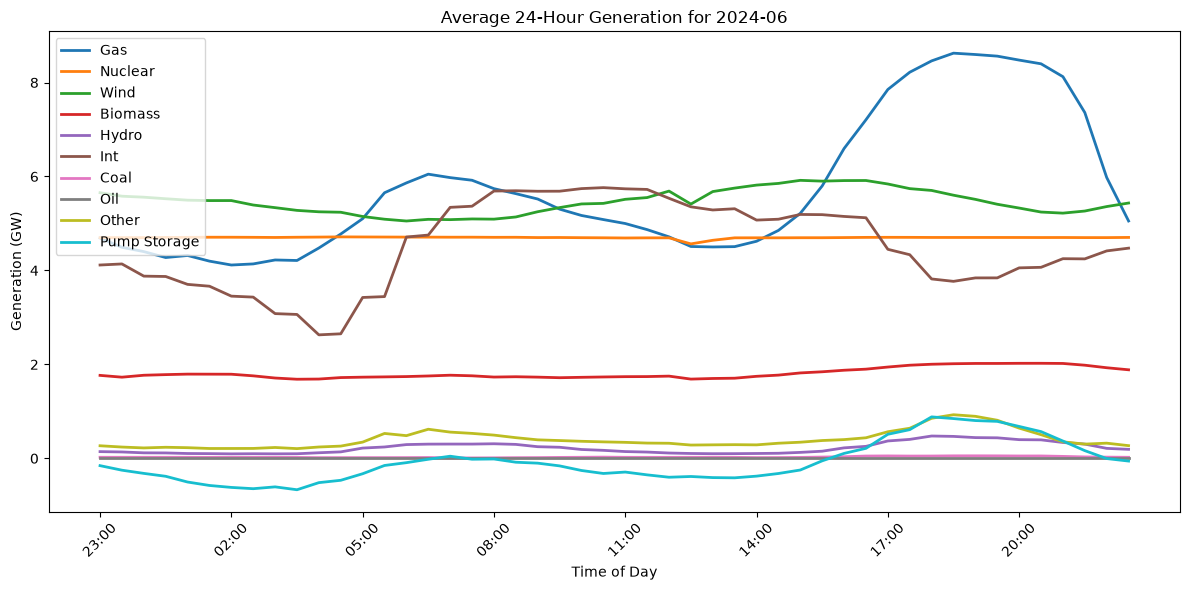



 24h plot for 2024-01...


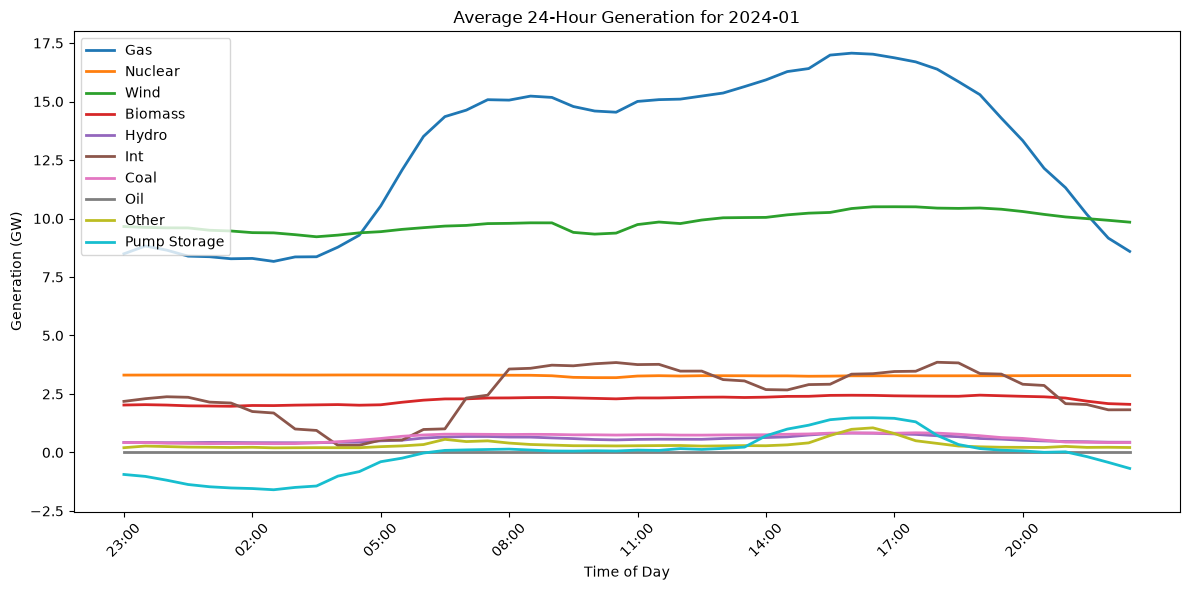

In [7]:
# m5: adapting previous code to find the elexon 24h and weekly average:

'''
in previous tasks, I completed the 24h plot and then a weekly plot.
however there may be variations across different days or weeks e.g as windy days and not so windy days.

these variations can be averaged out by doing 24h plot ( for a monthly average) + weekly plot (for a montly average)
note: i can also do 'for a yearly average' but for now i feel this more meaningful for analysis


'''

    
def plot_average_day_for_month(year, month):  
    
    # select some month
    print(f' 24h plot for {year}-{month:02d}...')
    
    # copy the matrix so it can be manipulated
    month_data = final_matrix_df.copy() 
    month_data['Date'] = pd.to_datetime(month_data['Date']) # convert to pandas datetime object for manipulation later
    
    # returns boolean column
    # filter for the specific year and month
    boolean_date_col = (month_data['Date'].dt.year == int(year)) & (month_data['Date'].dt.month == int(month))
    month_data = month_data[boolean_date_col] # want the full matrix where these rows are true
    
    # **** find the average of each settlement period
    daily_profile = month_data.groupby('Period').mean(numeric_only=True).reset_index()
    
    # hard code times
    time_labels = [
        '23:00', '23:30', '00:00', '00:30', '01:00', '01:30', '02:00', '02:30', 
        '03:00', '03:30', '04:00', '04:30', '05:00', '05:30', '06:00', '06:30', 
        '07:00', '07:30', '08:00', '08:30', '09:00', '09:30', '10:00', '10:30', 
        '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', 
        '15:00', '15:30', '16:00', '16:30', '17:00', '17:30', '18:00', '18:30', 
        '19:00', '19:30', '20:00', '20:30', '21:00', '21:30', '22:00', '22:30']
    
    # sort so that 23:00 matches 1 
    daily_profile = daily_profile.sort_values('Period') # sorts ascending by default
    
    # create a new column
    daily_profile['Time'] = time_labels
    
    plt.figure(figsize=(12, 6))
    
    fuels_to_plot = ['Gas', 'Nuclear', 'Wind', 'Biomass', 'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage']
    
    for fuel in fuels_to_plot:
        x_values = daily_profile['Time']
        y_values = daily_profile[fuel] / 1000  # access values in the relevant fueltype column + convert to GW
        plt.plot(x_values, y_values, label=fuel, linewidth=2) 
    
    # generate plots
    plt.title(f'Average 24-Hour Generation for {year}-{month:02d}')
    plt.ylabel('Generation (GW)')
    plt.xlabel('Time of Day')
    plt.xticks(ticks = range (0, 48, 6), rotation=45) # show certain time column values
    plt.yticks()
    plt.legend()
    plt.tight_layout()
    plt.show()

# choose some month 
print('summer month vs winter month:')
print('-----------------------------')
print('\n')

plot_average_day_for_month(2024, 6) 
print('\n')
plot_average_day_for_month(2024, 1) 



FuelType        Date  Period     Gas  Nuclear     Int  Biomass  Hydro    Coal  \
0         2016-01-01       1  5716.0   8289.0  2756.0      NaN  710.0  3434.0   
1         2016-01-01       2  6670.0   8292.0  2688.0      NaN  659.0  3583.0   
2         2016-01-01       3  6985.0   8297.0  2742.0      NaN  643.0  3865.0   
3         2016-01-01       4  6839.0   8285.0  2694.0      NaN  642.0  3772.0   
4         2016-01-01       5  6775.0   8279.0  2554.0      NaN  642.0  3555.0   

FuelType  Oil  Pump Storage    Wind   Other  
0         0.0        -108.0  4675.0  2040.0  
1         0.0          38.0  4334.0  2025.0  
2         0.0        -276.0  3994.0  1944.0  
3         0.0        -558.0  3615.0  1982.0  
4         0.0        -490.0  3031.0  2043.0  
Summer Week vs Winter Week:
---------------------------


Plotting average weekly profile for 2024-06...


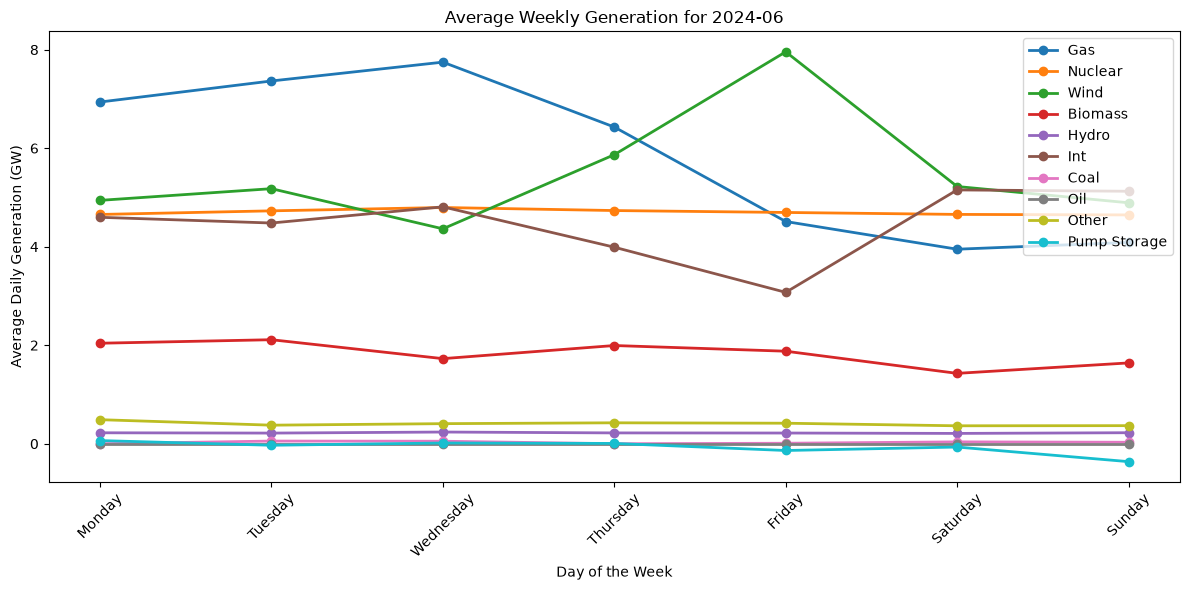


 
 
Plotting average weekly profile for 2024-01...


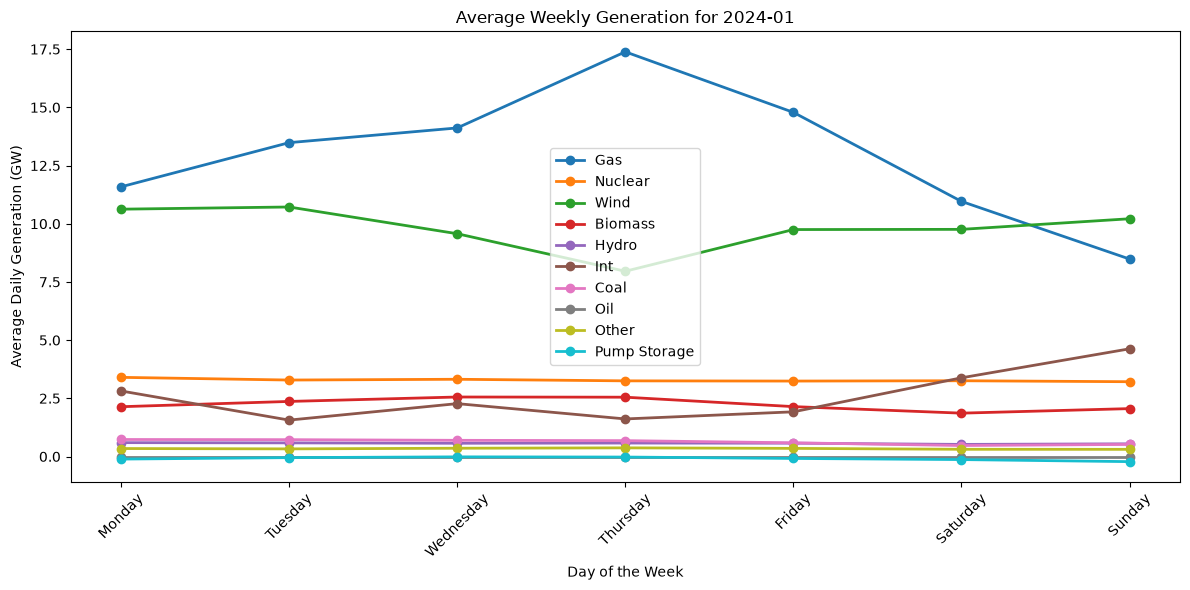

In [11]:
# m5: continued
print (final_matrix_df.head())

def plot_average_week_for_month(year, month):  
    
    # select some month
    print(f'Plotting average weekly profile for {year}-{month:02d}...')
    
    # copy the matrix so it can be manipulated
    month_data = final_matrix_df.copy() 
    month_data['Date'] = pd.to_datetime(month_data['Date']) # convert to pandas datetime object for manipulation later
    
    # returns boolean column
    # filter for the specific year and month
    boolean_date_col = (month_data['Date'].dt.year == int(year)) & (month_data['Date'].dt.month == int(month))

    # should have (48) * 30 rows 
    month_data = month_data[boolean_date_col] # want the full matrix where these rows are true
    #print(month_data)
    

    # **** we have data for avery single day for that month. find the average of each day for each fuel type. should be 10* 30 rows in the end
    daily_avg = month_data.groupby('Date').mean(numeric_only=True).reset_index()
    #print('len(daily_avg)')
    #print(daily_avg.head())
    
    # .dt.day_name() looks at the pandas datetime object and returns the name of day
    daily_avg['DayOfWeek'] = daily_avg['Date'].dt.day_name()
    #print(daily_avg.head())
    
    # *** group the 30 rows by day of the week into 7, one for each day of the week
    weekly_profile = daily_avg.groupby('DayOfWeek').mean(numeric_only=True).reset_index()
    #print(weekly_profile.head(50))
    
    # **** use dictionary to sort day of the week
    day_map = {'Monday':1, 'Tuesday':2, 'Wednesday':3, 'Thursday':4, 'Friday':5, 'Saturday':6, 'Sunday':7} # map each day to a number
    #print(day_map)
    weekly_profile['DayNum'] = weekly_profile['DayOfWeek'].map(day_map) # assign the corresponding number to each day of the wweek in the table
    #print(weekly_profile['DayNum'])
    #print(weekly_profile.head())

    weekly_profile = weekly_profile.sort_values('DayNum') # sort days in chron order from mon to sun
    #print(weekly_profile.head())
    
    # so that plot is big enough
    plt.figure(figsize=(12, 6))
    
    fuels_to_plot = ['Gas', 'Nuclear', 'Wind', 'Biomass', 'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage']
    
    for fuel in fuels_to_plot:
        x_values = weekly_profile['DayOfWeek'] # access values in day of week column
        y_values = weekly_profile[fuel] / 1000  # access values in the fueltype + convert to GW
        
        plt.plot(x_values, y_values, label=fuel, linewidth=2, marker='o') # draw a line with dots
    
    # generate plots
    plt.title(f'Average Weekly Generation for {year}-{month:02d}')
    plt.ylabel('Average Daily Generation (GW)')
    plt.xlabel('Day of the Week')

    plt.xticks(rotation=45)
    plt.yticks()
    plt.legend()
    plt.tight_layout() # ensures the tilted text doesn't get cut off at bottom
    plt.show()

print('Summer Week vs Winter Week:')
print('---------------------------')
print('\n')

plot_average_week_for_month(2024, 6)
print('\n \n ')
plot_average_week_for_month(2024, 1)

check columns
         Date  Period     Gas  Nuclear    Wind  Solar  Biomass  Hydro     Int  \
0  2019-01-01       1  5853.0   6924.0  9236.0    0.0   1052.0  405.0  1032.0   
1  2019-01-01       2  6292.0   6838.0  9297.0    0.0   1040.0  388.0  1054.0   
2  2019-01-01       3  5719.0   6834.0  9356.0    0.0   1026.0  372.0  1370.0   
3  2019-01-01       4  5020.0   6830.0  9135.0    0.0   1022.0  368.0  1334.0   
4  2019-01-01       5  4964.0   6827.0  8912.0    0.0   1018.0  355.0  1272.0   

   Coal  Oil  Other  Pump Storage  Wind_Capacity  Solar_Capacity   Demand  
0   0.0  0.0   64.0        -170.0            0.0             0.0  24396.0  
1   0.0  0.0   63.0          24.0            0.0             0.0  24996.0  
2   0.0  0.0   64.0         -26.0            0.0             0.0  24715.0  
3   0.0  0.0   63.0         -28.0            0.0             0.0  23744.0  
4   0.0  0.0   63.0        -542.0            0.0             0.0  22869.0  


summer month vs winter month (combined el

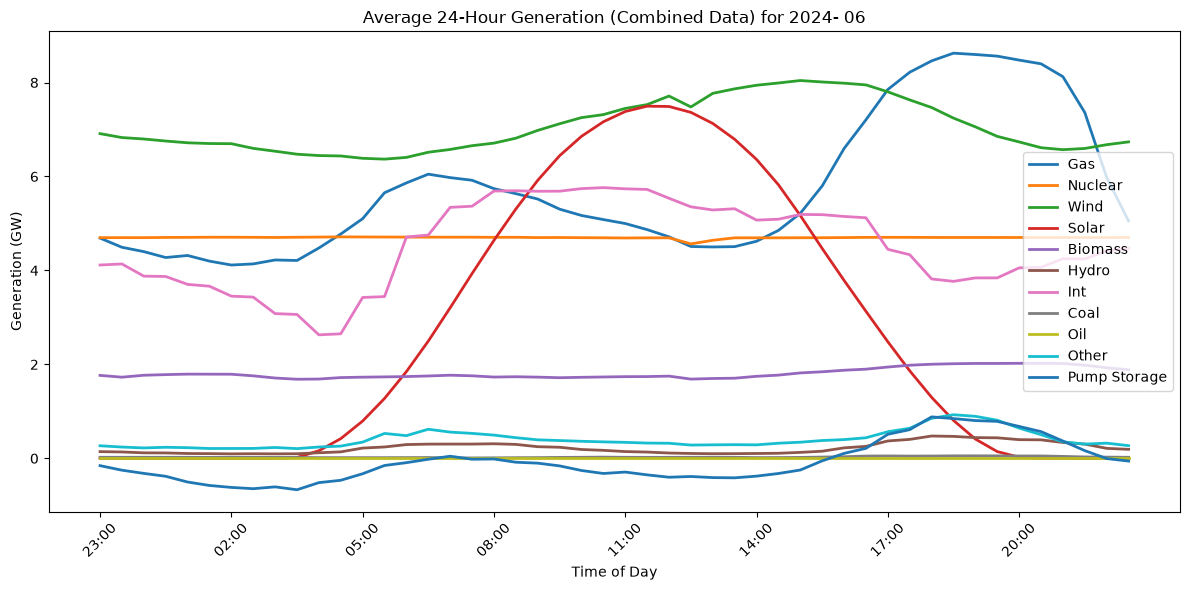



 24h plot for 2024-01...
check master_matrix columns
Index(['Date', 'Period', 'Gas', 'Nuclear', 'Wind', 'Solar', 'Biomass', 'Hydro',
       'Int', 'Coal', 'Oil', 'Other', 'Pump Storage', 'Wind_Capacity',
       'Solar_Capacity', 'Demand'],
      dtype='str')
 master_matrix has 122726  rows
filtered to 1488 rows for 2024-01
note: should around 30*48 =1440 rows
 after groupby there are 48 rows 
note: should be 48
   Period          Gas      Nuclear          Wind  Solar      Biomass  \
0       1  8491.225806  3307.193548  11969.903226    0.0  2027.806452   
1       2  8824.193548  3309.290323  11921.645161    0.0  2043.322581   
2       3  8647.774194  3309.967742  11890.612903    0.0  2026.129032   
3       4  8391.741935  3311.483871  11875.354839    0.0  1993.612903   
4       5  8366.612903  3311.129032  11761.806452    0.0  1985.645161   

        Hydro          Int        Coal  Oil       Other  Pump Storage  \
0  429.032258  2183.806452  421.161290  0.0  203.612903   -940.451613  

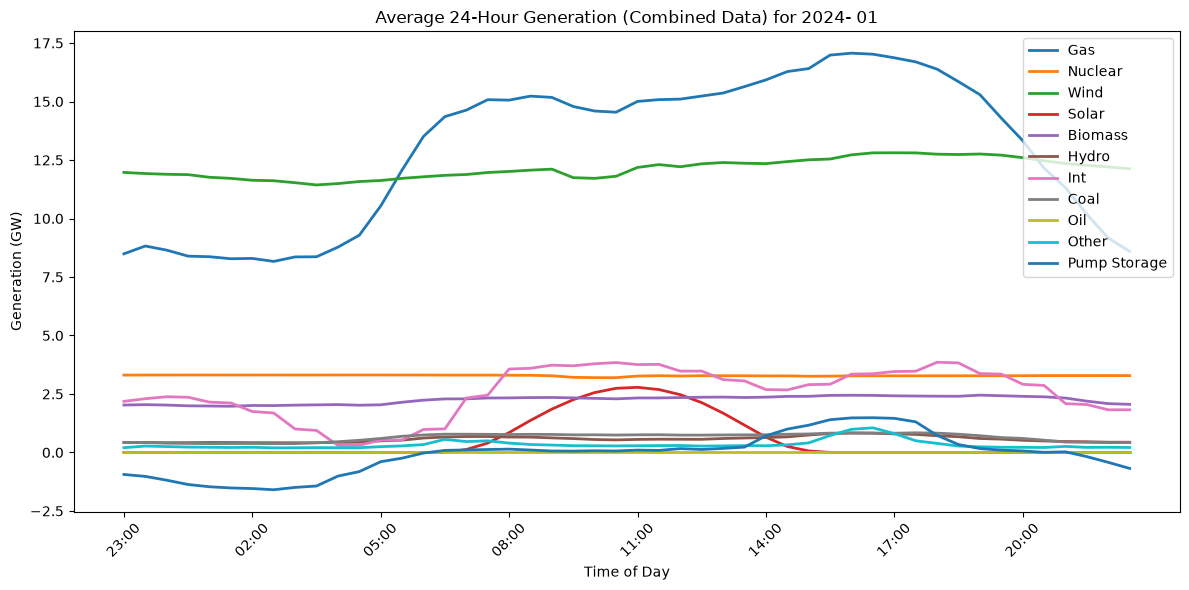

Summer Week vs Winter Week (combined elexon + neso):
----------------------------------------------------


Plotting average weekly profile for 2024-06...
check master_matrix columns
Index(['Date', 'Period', 'Gas', 'Nuclear', 'Wind', 'Solar', 'Biomass', 'Hydro',
       'Int', 'Coal', 'Oil', 'Other', 'Pump Storage', 'Wind_Capacity',
       'Solar_Capacity', 'Demand'],
      dtype='str')
master_matrix has 122726  rows
filtered to 1440 rows for 2024-06
note: should around 30*48 =1440 rows
 after groupby there are 30 rows 
note: should be around 30
 after groupby day of week there are 7 rows 
note: should be 7


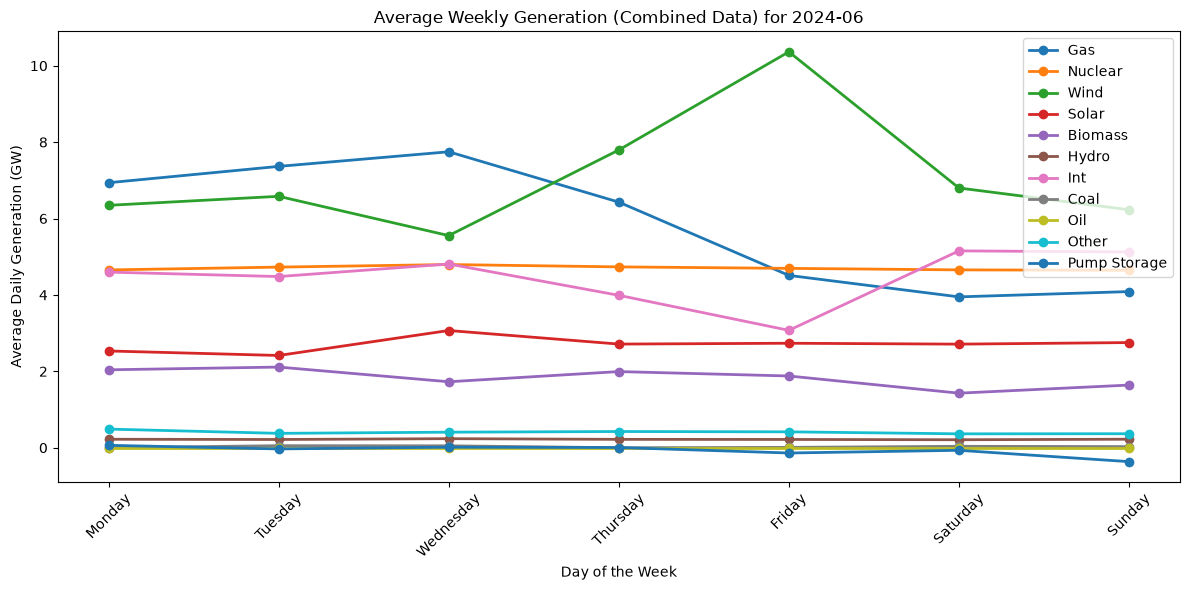


 
 
Plotting average weekly profile for 2024-01...
check master_matrix columns
Index(['Date', 'Period', 'Gas', 'Nuclear', 'Wind', 'Solar', 'Biomass', 'Hydro',
       'Int', 'Coal', 'Oil', 'Other', 'Pump Storage', 'Wind_Capacity',
       'Solar_Capacity', 'Demand'],
      dtype='str')
master_matrix has 122726  rows
filtered to 1488 rows for 2024-01
note: should around 30*48 =1440 rows
 after groupby there are 31 rows 
note: should be around 30
 after groupby day of week there are 7 rows 
note: should be 7


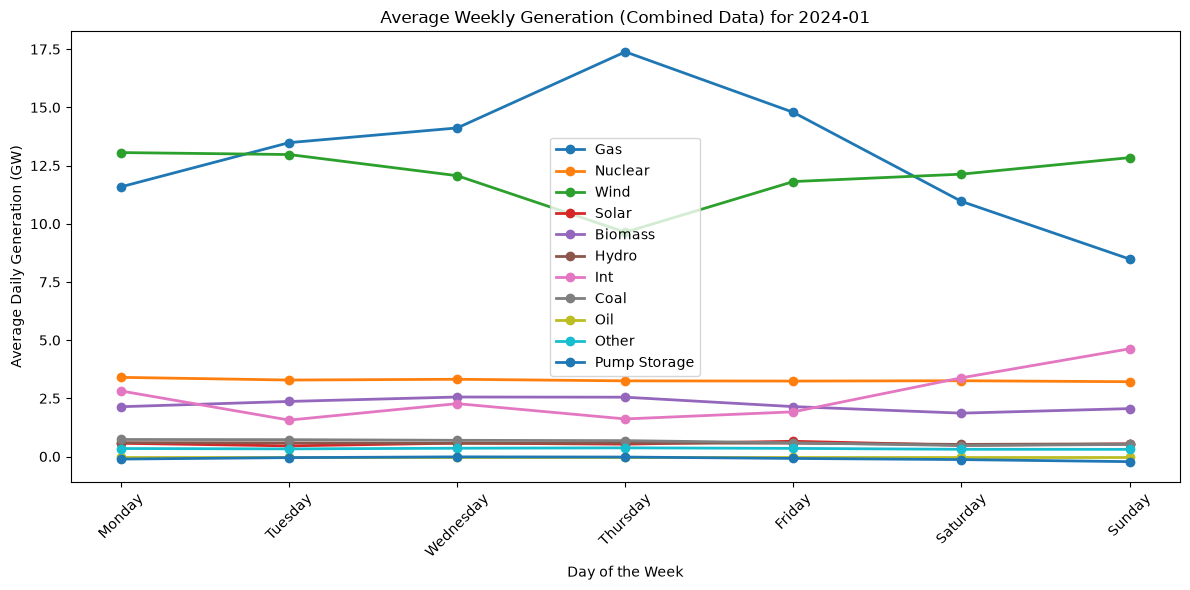

In [8]:
# m7: updated... elexon + neso plots (24hr, weekly)

'''
i tried to adapt the 24hr and weekly elxon code to generate plots
included edits in stars below

can try to make a demand vs time graph too later
'''


print('check columns')
print(master_matrix.head())
print('\n')

def plot_average_day_for_month_master(year, month):  
    
    # select some month
    print(f' 24h plot for {year}-{month:02d}...')
    
    # ****use combined master matrix instead of just final_matrix_df
    month_data = master_matrix.copy() 
    
    print('check master_matrix columns')
    print(month_data.columns)
    print(f' master_matrix has {len(month_data)}  rows')
    
    month_data['Date'] = pd.to_datetime(month_data['Date']) # convert to pandas datetime object for manipulation later
    
    # returns boolean column
    # filter for the specific year and month
    boolean_date_col = (month_data['Date'].dt.year == int(year)) & (month_data['Date'].dt.month == int(month))
    month_data = month_data[boolean_date_col] # want the full matrix where these rows are true
    
    print(f'filtered to {len(month_data)} rows for {year}-{month:02d}')
    print('note: should around 30*48 =1440 rows')
    
    # **** find the average of each settlement period
    daily_profile = month_data.groupby('Period').mean(numeric_only=True).reset_index()
    
    print(f' after groupby there are {len(daily_profile)} rows ')
    print('note: should be 48')
    print(daily_profile.head())
    
    # hard code times
    time_labels = [
        '23:00', '23:30', '00:00', '00:30', '01:00', '01:30', '02:00', '02:30', 
        '03:00', '03:30', '04:00', '04:30', '05:00', '05:30', '06:00', '06:30', 
        '07:00', '07:30', '08:00', '08:30', '09:00', '09:30', '10:00', '10:30', 
        '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', 
        '15:00', '15:30', '16:00', '16:30', '17:00', '17:30', '18:00', '18:30', 
        '19:00', '19:30', '20:00', '20:30', '21:00', '21:30', '22:00', '22:30']
    
    # sort so 23:00 matches 1 
    daily_profile = daily_profile.sort_values('Period') # sorts ascending by default
    
    # create a new column
    daily_profile['Time'] = time_labels
    
    plt.figure(figsize=(12, 6))
    
    fuels_to_plot = ['Gas', 'Nuclear', 'Wind','Solar', 'Biomass', 'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage']
    
    for fuel in fuels_to_plot:
        x_values = daily_profile['Time']
        y_values = daily_profile[fuel] / 1000  # access values in the relevant fueltype column + convert to GW
        plt.plot(x_values, y_values, label=fuel, linewidth=2) 
    
    # generate plots
    plt.title(f'Average 24-Hour Generation (Combined Data) for {year}- {month:02d}')
    plt.ylabel('Generation (GW)')
    plt.xlabel('Time of Day')
    plt.xticks(ticks = range (0, 48, 6), rotation=45) # show certain time column values
    plt.yticks()
    plt.legend()
    plt.tight_layout()
    plt.show()

# choose some month 
print('summer month vs winter month (combined elexon + neso):')
print('------------------------------------------------------')
print('\n')

plot_average_day_for_month_master(2024, 6) 
print('\n')
plot_average_day_for_month_master(2024, 1) 



'''
'''


def plot_average_week_for_month_master(year, month):  
    
    # select some month
    print(f'Plotting average weekly profile for {year}-{month:02d}...') 
    
    # ****use combined master matrix instead of just final_matrix_df
    month_data = master_matrix.copy() 
    
    print('check master_matrix columns')
    print(month_data.columns)
    print(f'master_matrix has {len(month_data)}  rows')
    
    month_data['Date'] = pd.to_datetime(month_data['Date']) # convert to pandas datetime object for manipulation later
    
    # returns boolean column
    # filter for the specific year and month
    boolean_date_col = (month_data['Date'].dt.year == int(year)) & (month_data['Date'].dt.month == int(month))

    # should have (48) * 30 rows 
    month_data = month_data[boolean_date_col] # want the full matrix where these rows are true
    
    print(f'filtered to {len(month_data)} rows for {year}-{month:02d}')
    print('note: should around 30*48 =1440 rows')
    
    # **** we have data for avery single day for that month. find the average of each day for each fuel type. should be 11* 30 rows in the end
    daily_avg = month_data.groupby('Date').mean(numeric_only=True).reset_index()
    
    print(f' after groupby there are {len(daily_avg)} rows ')
    print('note: should be around 30')
    
    # .dt.day_name() looks at the pandas datetime object and returns the name of day
    daily_avg['DayOfWeek'] = daily_avg['Date'].dt.day_name()
    
    # *** group the 30 rows by day of the week into 7, one for each day of the week
    weekly_profile = daily_avg.groupby('DayOfWeek').mean(numeric_only=True).reset_index()
    
    print(f' after groupby day of week there are {len(weekly_profile)} rows ')
    print('note: should be 7')
    
    # **** use dictionary to sort day of the week
    day_map = {'Monday':1, 'Tuesday':2, 'Wednesday':3, 'Thursday':4, 'Friday':5, 'Saturday':6, 'Sunday':7} # map each day to a number
    weekly_profile['DayNum'] = weekly_profile['DayOfWeek'].map(day_map) # assign the corresponding number to each day of the week in the table

    weekly_profile = weekly_profile.sort_values('DayNum') # sort days in chron order from mon to sun
    
    # so that plot is big enough
    plt.figure(figsize=(12, 6))
    
    fuels_to_plot = ['Gas', 'Nuclear', 'Wind','Solar', 'Biomass', 'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage']
    
    for fuel in fuels_to_plot:
        x_values = weekly_profile['DayOfWeek'] # access values in day of week column
        y_values = weekly_profile[fuel] / 1000  # access values in the fueltype + convert to GW
        
        plt.plot(x_values, y_values, label=fuel, linewidth=2, marker='o') # draw a line with dots
    
    # generate plots
    plt.title(f'Average Weekly Generation (Combined Data) for {year}-{month:02d}')
    plt.ylabel('Average Daily Generation (GW)')
    plt.xlabel('Day of the Week')

    plt.xticks(rotation=45)
    plt.yticks()
    plt.legend()
    plt.tight_layout() # ensures the tilted text doesn't get cut off at bottom
    plt.show()


print('Summer Week vs Winter Week (combined elexon + neso):')
print('----------------------------------------------------')
print('\n')

plot_average_week_for_month_master(2024, 6)
print('\n \n ')
plot_average_week_for_month_master(2024, 1)



''' Analysis

- summer in equator and winter at poles. 
- lattitue angle of countries
- when its summer at the equator its winter 
- angle of power incident from sun affected maximum power between plots

- winds is higher intenisy in summer compared to winter
- can't say much about int, its just about contracts
- everything is flat. 
- nuclear has no seasonal pattern, can depend on if reactors are flat

'''



In [14]:
# m8: elexon + neso plots (yearly averages)

'''
i will apply the demand plot from iamkate.com to the elexon + neso daily, weekly and monthly average plots LATER

for now, use the neso + elexon data : plot a comparison between two years and plot a comparison between every year between 2020 and 2025

i can use the m4 elexon code as the base

'''



# recall code below, for m4: will plot elexon monthly averages for a specific year

def plot_monthly_average_for_year(year):


    year_data = final_matrix_df.copy() # so matrix can be manipulated
    year_data['Date'] = pd.to_datetime(year_data['Date']) # converte to pandas dateime object for manipulation later
    
    # filter for the specific yea, month
    boolean_date_col = year_data['Date'].dt.year == int(year) # returns boolean column
    year_data = year_data[boolean_date_col] # want the full matrix where these rows are true
    year_data['MonthNum'] = year_data['Date'].dt.month

    

    # reset_index() turns 'MonthNum' back into normal column and now has a numerical index
    monthly_average = year_data.groupby('MonthNum').mean(numeric_only=True).reset_index()
    monthly_average = monthly_average.sort_values('MonthNum')
    #print(monthly_average.head())
    
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    # create plot big enough
    plt.figure(figsize=(12, 6))
    
    fuels_to_plot = ['Gas', 'Nuclear', 'Wind', 'Biomass', 'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage']
    
    for fuel in fuels_to_plot:
        x_values = monthly_average['MonthNum'] 
        y_values = monthly_average[fuel] / 1000 # convert to GW
        
        # draw a line with dots for each month
        plt.plot(x_values, y_values, label=fuel, linewidth=2, marker='o')
    
    # generate plots
    plt.title(f'Average Monthly Energy Generation for {year}')
    plt.ylabel('Average Monthly Generation (GW)')
    plt.xlabel('Month')
    plt.xticks(ticks=range(1, 13), labels=month_names, rotation=45)
    plt.yticks()
    plt.legend()
    plt.tight_layout() # ensures the tilted text doesn't get cut off at bottom
    plt.show()




#-----------------------------------------------------------------------

print('Yearly Monthly Average:')
print('-----------------------')
print('\n')

plot_monthly_average_for_year('2025') 
print('\n \n ')
plot_monthly_average_for_year('2024') 
print('\n \n')
plot_monthly_average_for_year('2023') 
print('\n \n')







Task 1: 2020 vs 2025
--------------------


comparing 2020 and 2025...
found 17570 rows for 2020
after groupby 2020 has 12 rows
note: should be exactly 12
debug: found 17520 rows for 2025
after groupby 2025 has 12 rows


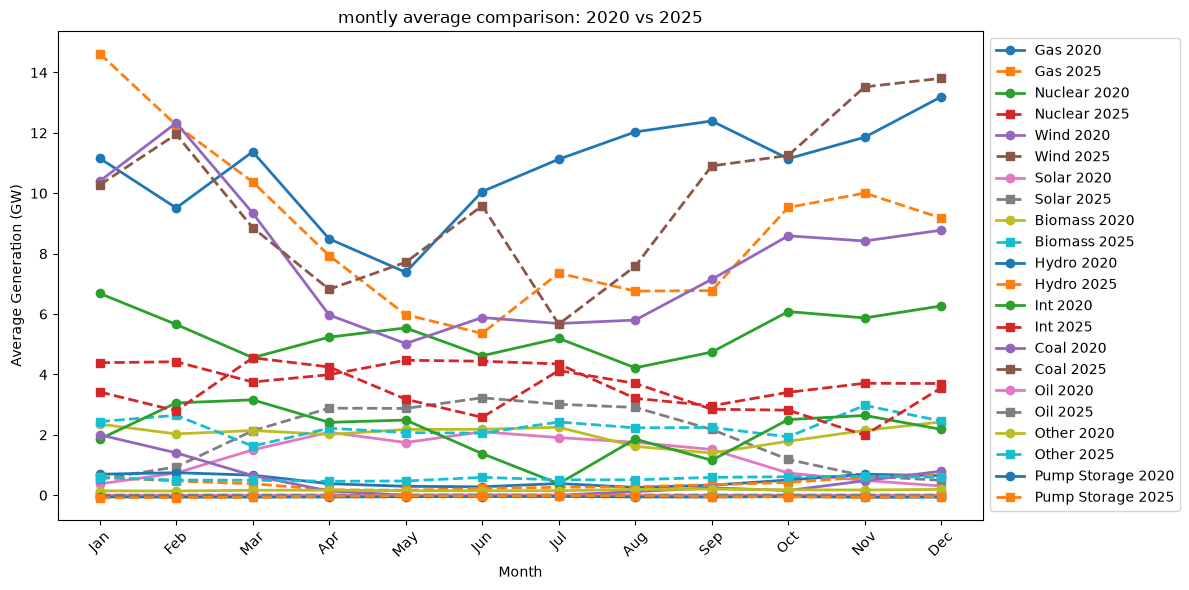

"\nit's difficult to ditinguish which is which\n\nperhaps, make one figure with two axes\nor 10 plots comparing 2020 vs 2025\n"

In [48]:
# m8: continued

# all on the same axes

def plot_monthly_comparison(year1, year2):
    print(f'comparing {year1} and {year2}...')
    
    # **** use combined master matrix
    all_data = master_matrix.copy()
    all_data['Date'] = pd.to_datetime(all_data['Date'])
    
    # do year 1
    bool_year1 = all_data['Date'].dt.year == int(year1)
    #print(bool_year1)
    data_y1 = all_data[bool_year1].copy()
    #print(data_y1.head())
    print(f'found {len(data_y1)} rows for {year1}')
    
    data_y1['MonthNum'] = data_y1['Date'].dt.month
    #print(data_y1['MonthNum'])
    avg_y1 = data_y1.groupby('MonthNum').mean(numeric_only=True).reset_index()
    print(f'after groupby {year1} has {len(avg_y1)} rows')
    print('note: should be exactly 12')
    
    # process year 2
    bool_year2 = all_data['Date'].dt.year == int(year2)
    data_y2 = all_data[bool_year2].copy()
    print(f'found {len(data_y2)} rows for {year2}')
    
    data_y2['MonthNum'] = data_y2['Date'].dt.month
    avg_y2 = data_y2.groupby('MonthNum').mean(numeric_only=True).reset_index()
    print(f'after groupby {year2} has {len(avg_y2)} rows')
    
    # plotting
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    plt.figure(figsize=(12, 6))
    
    fuels_to_plot = ['Gas', 'Nuclear', 'Wind', 'Solar', 'Biomass', 'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage']
    
    # **** loop through fuels and plot both years
    for fuel in fuels_to_plot:
        
        # year 1 solid line
        plt.plot(avg_y1['MonthNum'], avg_y1[fuel]/1000, label=f'{fuel} {year1}', linewidth=2, marker='o')
        # year 2 dashed line so we can tell them apart
        plt.plot(avg_y2['MonthNum'], avg_y2[fuel]/1000, label=f'{fuel} {year2}', linewidth=2, marker='s', linestyle='--')
        
    plt.title(f'montly average comparison: {year1} vs {year2}')
    plt.ylabel('Average Generation (GW)')
    plt.xlabel('Month')
    plt.xticks(ticks=range(1, 13), labels=month_names, rotation=45)
    plt.yticks()
    
    # put legend outside 
    plt.legend(bbox_to_anchor=(1, 1), loc='upper left')  # place upper left corner of legend box at 11
    plt.tight_layout()
    plt.show()


print('2020 vs 2025')
print('--------------------')
print('\n')

plot_monthly_comparison(2020, 2025)


'''
it's difficult to ditinguish which is which

perhaps, make one figure with two axes
or 10 plots comparing 2020 vs 2025
'''






 

Continuous 2020-2025
----------------------------


plotting from 2020 to 2025...
found 105221 rows
note: should be around 6 * 365 * 48 = 105120 rows
after groupby there are 72 rows
note: should be exactly 72


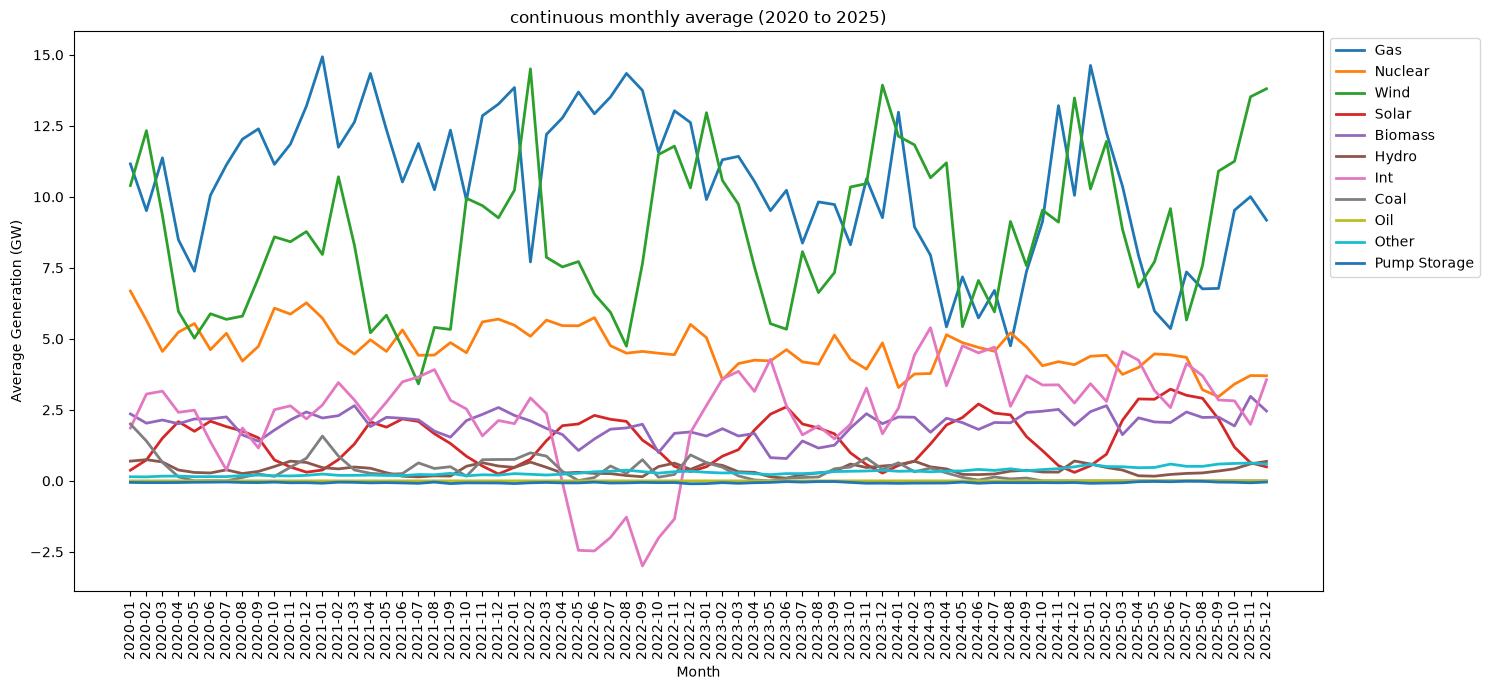

In [51]:
# m8: continued

# for some year range

def plot_continous_timeline(start_year, end_year):
    print(f'plotting from {start_year} to {end_year}...')
    
    timeline_data = master_matrix.copy()
    timeline_data['Date'] = pd.to_datetime(timeline_data['Date'])
    
    # filter for the years
    bool_years = (timeline_data['Date'].dt.year >= int(start_year)) & (timeline_data['Date'].dt.year <= int(end_year))
    #print(bool_years)
    timeline_data = timeline_data[bool_years].copy()
    
    print(f'found {len(timeline_data)} rows')
    print('note: should be around 6 * 365 * 48 = 105120 rows') # may be extra rows since we merged using 'outer'
    
    # **** create a year month column to group by
    # strftime makes it a string like '2020-01'
    timeline_data['YearMonth'] = timeline_data['Date'].dt.strftime('%Y-%m')
    # use format codes %Y %m %d
    # %Y / %y is 4 / 2 digit year
    
    
    # groupby to get 72 rows
    monthly_avg = timeline_data.groupby('YearMonth').mean(numeric_only=True).reset_index()
    #print(monthly_avg.head())
    monthly_avg = monthly_avg.sort_values('YearMonth')
    
    print(f'after groupby there are {len(monthly_avg)} rows')
    print('note: should be exactly 72')
    
    plt.figure(figsize=(15, 7)) 
    
    fuels_to_plot = ['Gas', 'Nuclear', 'Wind', 'Solar', 'Biomass', 'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage']
    
    for fuel in fuels_to_plot:
        x_values = monthly_avg['YearMonth']
        y_values = monthly_avg[fuel] / 1000
        plt.plot(x_values, y_values, label=fuel, linewidth=2)
        
    plt.title(f'continuous monthly average ({start_year} to {end_year})')
    plt.ylabel('Average Generation (GW)')
    plt.xlabel('Month')
    
    plt.xticks(rotation=90)
    plt.yticks()

    
    # put legend outside    
    plt.legend(bbox_to_anchor=(1, 1), loc='upper left') # place upper left corner of legend box at 11
    plt.tight_layout()
    plt.show()


print('\n \n')
print('Continuous 2020-2025')
print('----------------------------')
print('\n')

plot_continous_timeline(2020, 2025)

Storage Plots
-----------------


 24h plot for 2025-06...
check final_matrix_df columns
Index(['Date', 'Period', 'Gas', 'Nuclear', 'Int', 'Biomass', 'Hydro', 'Coal',
       'Oil', 'Pump Storage', 'Wind', 'Other'],
      dtype='str', name='FuelType')
 final_matrix_df has 183160  rows
filtered to 1440 rows for 2025-06
note: should around 30*48 =1440 rows
 after groupby there are 48 rows 
note: should be 48
FuelType  Period          Gas      Nuclear          Int      Biomass  \
0              1  5061.733333  4455.400000  1923.600000  2235.600000   
1              2  4708.966667  4458.000000  1942.133333  2177.100000   
2              3  4495.233333  4457.733333  1788.466667  2117.700000   
3              4  4365.700000  4456.033333  1784.600000  2079.033333   
4              5  4386.000000  4449.433333  1452.066667  2098.633333   

FuelType       Hydro  Coal  Oil  Pump Storage         Wind       Other  
0         198.000000   0.0  0.0    -28.866667  7769.666667  270.666667  
1         19

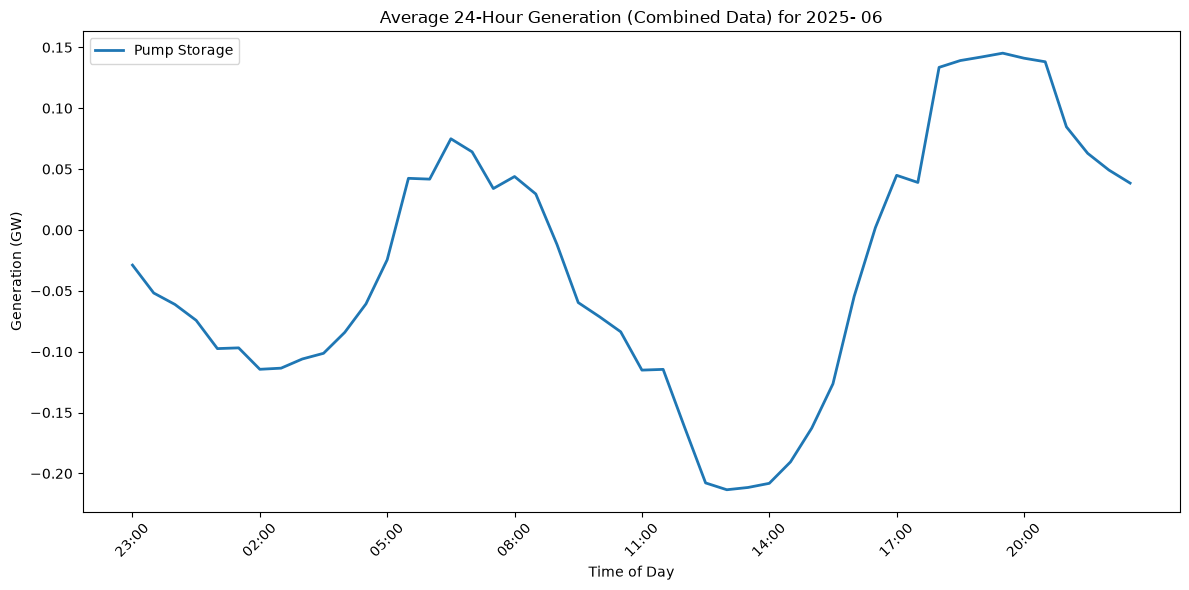

 24h plot for 2025-01...
check final_matrix_df columns
Index(['Date', 'Period', 'Gas', 'Nuclear', 'Int', 'Biomass', 'Hydro', 'Coal',
       'Oil', 'Pump Storage', 'Wind', 'Other'],
      dtype='str', name='FuelType')
 final_matrix_df has 183160  rows
filtered to 1488 rows for 2025-01
note: should around 30*48 =1440 rows
 after groupby there are 48 rows 
note: should be 48
FuelType  Period          Gas      Nuclear          Int      Biomass  \
0              1  9301.225806  4403.516129  3354.580645  2161.096774   
1              2  9437.903226  4403.580645  3445.161290  2153.032258   
2              3  9410.548387  4403.935484  3467.096774  2148.419355   
3              4  9117.967742  4405.870968  3437.935484  2152.806452   
4              5  8905.387097  4404.967742  3236.838710  2155.580645   

FuelType       Hydro  Coal  Oil  Pump Storage         Wind       Other  
0         484.000000   0.0  0.0   -710.709677  8303.612903  354.000000  
1         480.225806   0.0  0.0   -716.903226 

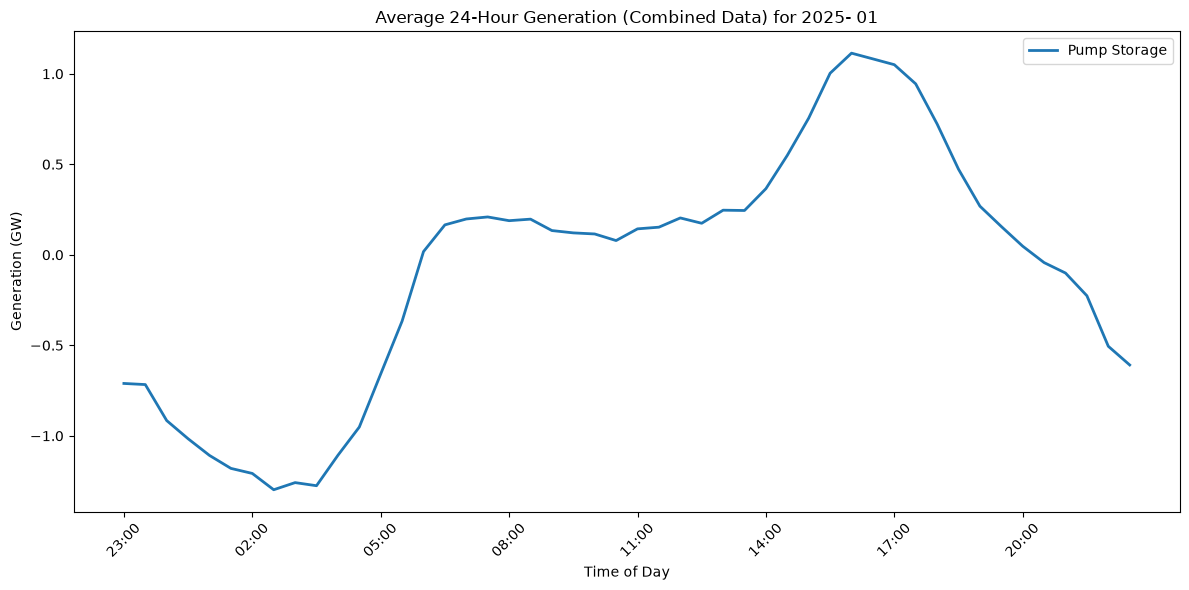



Plotting average weekly profile for 2025-06...
check final_matrix_df columns
Index(['Date', 'Period', 'Gas', 'Nuclear', 'Int', 'Biomass', 'Hydro', 'Coal',
       'Oil', 'Pump Storage', 'Wind', 'Other'],
      dtype='str', name='FuelType')
final_matrix_df has 183160  rows
filtered to 1440 rows for 2025-06
note: should around 30*48 =1440 rows
 after groupby there are 30 rows 
note: should be around 30
 after groupby day of week there are 7 rows 
note: should be 7


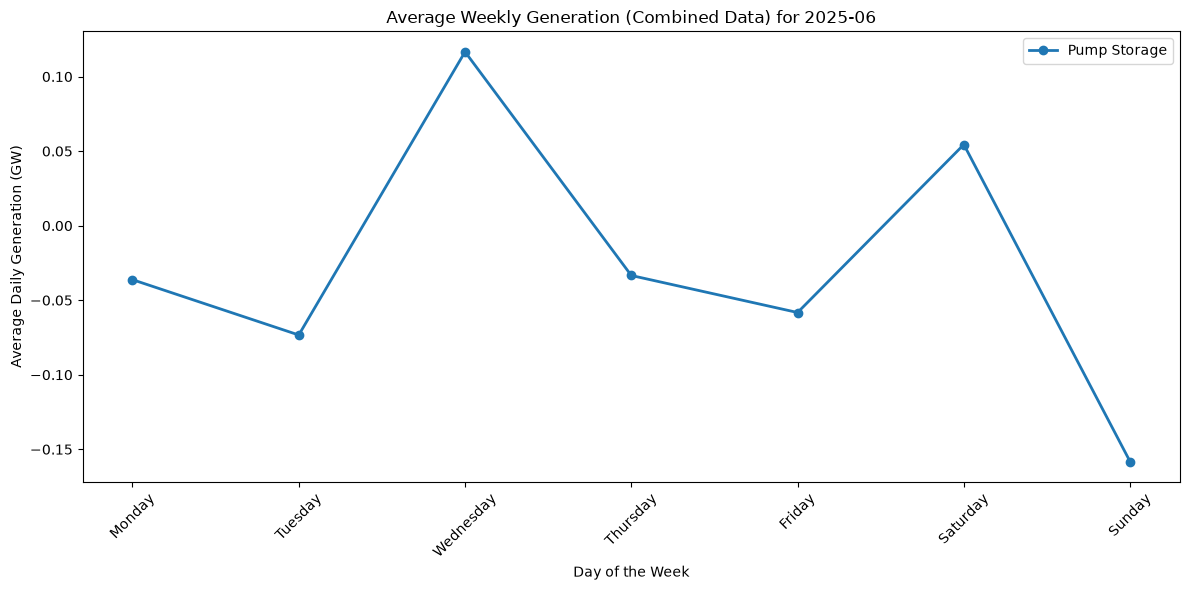

Plotting average weekly profile for 2025-01...
check final_matrix_df columns
Index(['Date', 'Period', 'Gas', 'Nuclear', 'Int', 'Biomass', 'Hydro', 'Coal',
       'Oil', 'Pump Storage', 'Wind', 'Other'],
      dtype='str', name='FuelType')
final_matrix_df has 183160  rows
filtered to 1488 rows for 2025-01
note: should around 30*48 =1440 rows
 after groupby there are 31 rows 
note: should be around 30
 after groupby day of week there are 7 rows 
note: should be 7


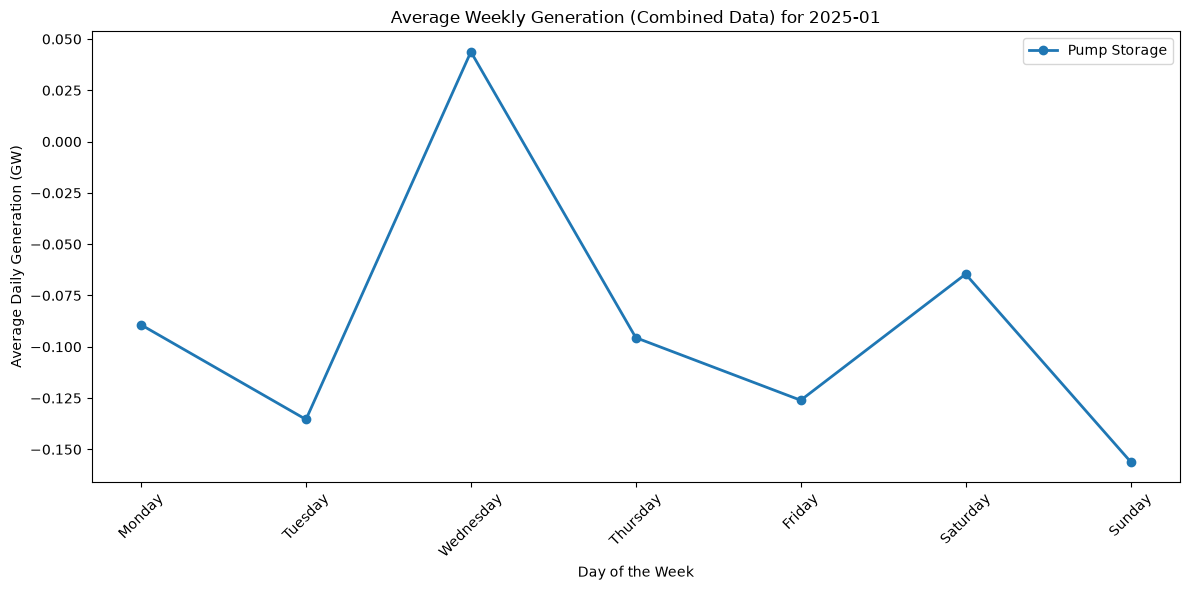



comparing 2016 and 2025...
found 17552 rows for 2016
after groupby 2016 has 12 rows
note: should be exactly 12
debug: found 17520 rows for 2025
after groupby 2025 has 12 rows


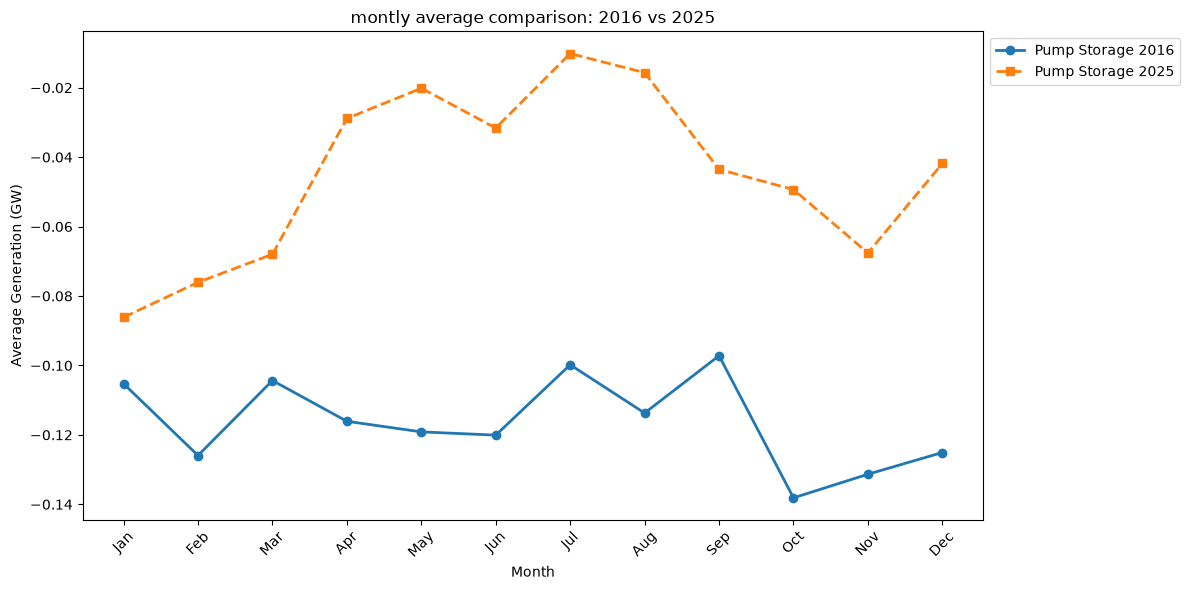



plotting from 2016 to 2025...
found 175212 rows
note: should be around 6 * 365 * 48 = 105120 rows
after groupby there are 120 rows
note: should be exactly 72


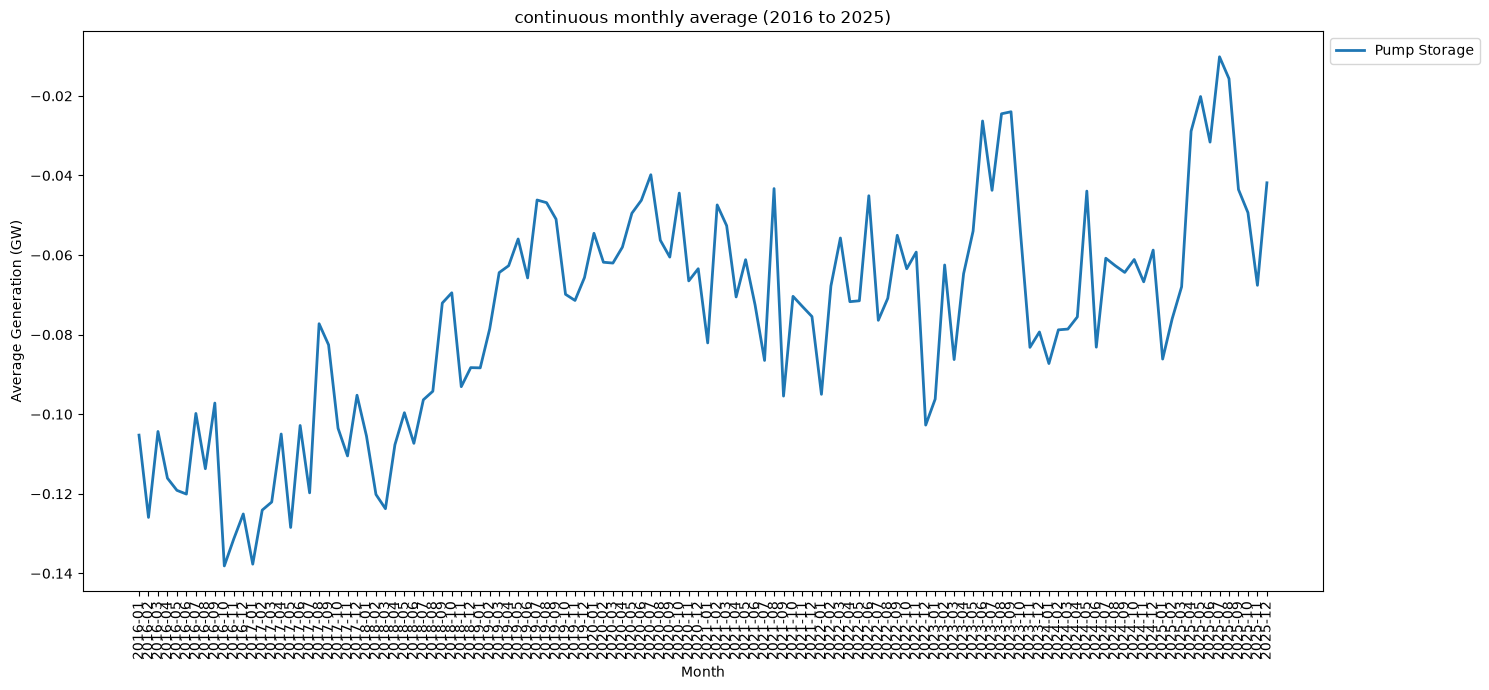

In [66]:
# m8: elexon + neso (24hr, weekly and yearly averages) for only pump storage

'''
pump sotrage is a value only present in elexon and elexon goes back to 2016
so dont need to use master_matrix (elexon+neso) and cna use final_matrix (elexon only) instead 
ill use m7 and m8

- ve => uphill (giving to storage)
+ ve => downwhill (using storage)

'''



def plot_storage_day(year, month):  
    
    # select some month
    print(f' 24h plot for {year}-{month:02d}...')
    
    # ****use final_matrix_df instead of master_matrix to get data back to 2016
    month_data = final_matrix_df.copy() 
    
    print('check final_matrix_df columns')
    print(month_data.columns)
    print(f' final_matrix_df has {len(month_data)}  rows')
    
    month_data['Date'] = pd.to_datetime(month_data['Date']) # convert to pandas datetime object for manipulation later
    
    # returns boolean column
    # filter for the specific year and month
    boolean_date_col = (month_data['Date'].dt.year == int(year)) & (month_data['Date'].dt.month == int(month))
    month_data = month_data[boolean_date_col] # want the full matrix where these rows are true
    
    print(f'filtered to {len(month_data)} rows for {year}-{month:02d}')
    print('note: should around 30*48 =1440 rows')
    
    # **** find the average of each settlement period
    daily_profile = month_data.groupby('Period').mean(numeric_only=True).reset_index()
    
    print(f' after groupby there are {len(daily_profile)} rows ')
    print('note: should be 48')
    print(daily_profile.head())
    
    # hard code times
    time_labels = [
        '23:00', '23:30', '00:00', '00:30', '01:00', '01:30', '02:00', '02:30', 
        '03:00', '03:30', '04:00', '04:30', '05:00', '05:30', '06:00', '06:30', 
        '07:00', '07:30', '08:00', '08:30', '09:00', '09:30', '10:00', '10:30', 
        '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', 
        '15:00', '15:30', '16:00', '16:30', '17:00', '17:30', '18:00', '18:30', 
        '19:00', '19:30', '20:00', '20:30', '21:00', '21:30', '22:00', '22:30']
    
    # sort so 23:00 matches 1 
    daily_profile = daily_profile.sort_values('Period') # sorts ascending by default
    
    # create a new column
    daily_profile['Time'] = time_labels
    
    plt.figure(figsize=(12, 6))
    
    fuels_to_plot = ['Pump Storage']
    
    for fuel in fuels_to_plot:
        x_values = daily_profile['Time']
        y_values = daily_profile[fuel] / 1000  # access values in the relevant fueltype column + convert to GW
        plt.plot(x_values, y_values, label=fuel, linewidth=2) 
    
    # generate plots
    plt.title(f'Average 24-Hour Generation (Combined Data) for {year}- {month:02d}')
    plt.ylabel('Generation (GW)')
    plt.xlabel('Time of Day')
    plt.xticks(ticks = range (0, 48, 6), rotation=45) # show certain time column values
    plt.yticks()
    plt.legend()
    plt.tight_layout()
    plt.show()




def plot_storage_week(year, month):  
    
    # select some month
    print(f'Plotting average weekly profile for {year}-{month:02d}...') 
    
    # ****use final_matrix_df instead of master_matrix to get data back to 2016
    month_data = final_matrix_df.copy() 
    
    print('check final_matrix_df columns')
    print(month_data.columns)
    print(f'final_matrix_df has {len(month_data)}  rows')
    
    month_data['Date'] = pd.to_datetime(month_data['Date']) # convert to pandas datetime object for manipulation later
    
    # returns boolean column
    # filter for the specific year and month
    boolean_date_col = (month_data['Date'].dt.year == int(year)) & (month_data['Date'].dt.month == int(month))

    # should have (48) * 30 rows 
    month_data = month_data[boolean_date_col] # want the full matrix where these rows are true
    
    print(f'filtered to {len(month_data)} rows for {year}-{month:02d}')
    print('note: should around 30*48 =1440 rows')
    
    # **** we have data for avery single day for that month. find the average of each day for each fuel type. should be 11* 30 rows in the end
    daily_avg = month_data.groupby('Date').mean(numeric_only=True).reset_index()
    
    print(f' after groupby there are {len(daily_avg)} rows ')
    print('note: should be around 30')
    
    # .dt.day_name() looks at the pandas datetime object and returns the name of day
    daily_avg['DayOfWeek'] = daily_avg['Date'].dt.day_name()
    
    # *** group the 30 rows by day of the week into 7, one for each day of the week
    weekly_profile = daily_avg.groupby('DayOfWeek').mean(numeric_only=True).reset_index()
    
    print(f' after groupby day of week there are {len(weekly_profile)} rows ')
    print('note: should be 7')
    
    # **** use dictionary to sort day of the week
    day_map = {'Monday':1, 'Tuesday':2, 'Wednesday':3, 'Thursday':4, 'Friday':5, 'Saturday':6, 'Sunday':7} # map each day to a number
    weekly_profile['DayNum'] = weekly_profile['DayOfWeek'].map(day_map) # assign the corresponding number to each day of the week in the table

    weekly_profile = weekly_profile.sort_values('DayNum') # sort days in chron order from mon to sun
    
    # so that plot is big enough
    plt.figure(figsize=(12, 6))
    
    fuels_to_plot = ['Pump Storage']
    
    for fuel in fuels_to_plot:
        x_values = weekly_profile['DayOfWeek'] # access values in day of week column
        y_values = weekly_profile[fuel] / 1000  # access values in the fueltype + convert to GW
        
        plt.plot(x_values, y_values, label=fuel, linewidth=2, marker='o') # draw a line with dots
    
    # generate plots
    plt.title(f'Average Weekly Generation (Combined Data) for {year}-{month:02d}')
    plt.ylabel('Average Daily Generation (GW)')
    plt.xlabel('Day of the Week')

    plt.xticks(rotation=45)
    plt.yticks()
    plt.legend()
    plt.tight_layout() # ensures the tilted text doesn't get cut off at bottom
    plt.show()




def plot_storage_year(year1, year2):
    print(f'comparing {year1} and {year2}...')
    
    # **** use final_matrix_df instead of master_matrix to get data back to 2016
    all_data = final_matrix_df.copy()
    all_data['Date'] = pd.to_datetime(all_data['Date'])
    
    # do year 1
    bool_year1 = all_data['Date'].dt.year == int(year1)
    #print(bool_year1)
    data_y1 = all_data[bool_year1].copy()
    #print(data_y1.head())
    print(f'found {len(data_y1)} rows for {year1}')
    
    data_y1['MonthNum'] = data_y1['Date'].dt.month
    #print(data_y1['MonthNum'])
    avg_y1 = data_y1.groupby('MonthNum').mean(numeric_only=True).reset_index()

    # note: removed the print(data_y1.head(100000)) because it will freeze the notebook!
    
    print(f'after groupby {year1} has {len(avg_y1)} rows')
    print('note: should be exactly 12')
    
    # process year 2
    bool_year2 = all_data['Date'].dt.year == int(year2)
    data_y2 = all_data[bool_year2].copy()
    print(f'
    found {len(data_y2)} rows for {year2}')
    
    data_y2['MonthNum'] = data_y2['Date'].dt.month
    avg_y2 = data_y2.groupby('MonthNum').mean(numeric_only=True).reset_index()
    print(f'after groupby {year2} has {len(avg_y2)} rows')
    
    # plotting
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    plt.figure(figsize=(12, 6))
    
    fuels_to_plot = ['Pump Storage']
    
    # **** loop through fuels and plot both years
    for fuel in fuels_to_plot:
        
        # year 1 solid line
        plt.plot(avg_y1['MonthNum'], avg_y1[fuel]/1000, label=f'{fuel} {year1}', linewidth=2, marker='o')
        # year 2 dashed line so we can tell them apart
        plt.plot(avg_y2['MonthNum'], avg_y2[fuel]/1000, label=f'{fuel} {year2}', linewidth=2, marker='s', linestyle='--')
        
    plt.title(f'montly average comparison: {year1} vs {year2}')
    plt.ylabel('Average Generation (GW)')
    plt.xlabel('Month')
    plt.xticks(ticks=range(1, 13), labels=month_names, rotation=45)
    plt.yticks()
    
    # put legend outside 
    plt.legend(bbox_to_anchor=(1, 1), loc='upper left')  # place upper left corner of legend box at 11
    plt.tight_layout()
    plt.show()






def plot_storage_all_years(start_year, end_year):
    print(f'plotting from {start_year} to {end_year}...')
    
    # **** use final_matrix_df instead of master_matrix to get data back to 2016
    timeline_data = final_matrix_df.copy()
    timeline_data['Date'] = pd.to_datetime(timeline_data['Date'])
    
    # filter for the years
    bool_years = (timeline_data['Date'].dt.year >= int(start_year)) & (timeline_data['Date'].dt.year <= int(end_year))
    #print(bool_years)
    timeline_data = timeline_data[bool_years].copy()
    
    print(f'found {len(timeline_data)} rows')
    print('note: should be around 6 * 365 * 48 = 105120 rows') # may be extra rows since we merged using 'outer'
    
    # **** create a year month column to group by
    # strftime makes it a string like '2020-01'
    timeline_data['YearMonth'] = timeline_data['Date'].dt.strftime('%Y-%m')
    # use format codes %Y %m %d
    # %Y / %y is 4 / 2 digit year
    
    
    # groupby to get 72 rows
    monthly_avg = timeline_data.groupby('YearMonth').mean(numeric_only=True).reset_index()
    #print(monthly_avg.head())
    monthly_avg = monthly_avg.sort_values('YearMonth')
    #print(monthly_avg.head())
    
    print(f'after groupby there are {len(monthly_avg)} rows')
    print('note: should be exactly 72')
    
    plt.figure(figsize=(15, 7)) 
    
    fuels_to_plot = ['Pump Storage']
    
    for fuel in fuels_to_plot:
        x_values = monthly_avg['YearMonth']
        y_values = monthly_avg[fuel] / 1000
        plt.plot(x_values, y_values, label=fuel, linewidth=2)
        
    plt.title(f'continuous monthly average ({start_year} to {end_year})')
    plt.ylabel('Average Generation (GW)')
    plt.xlabel('Month')
    
    plt.xticks(rotation=90)
    plt.yticks()

    
    # put legend outside    
    plt.legend(bbox_to_anchor=(1, 1), loc='upper left') # place upper left corner of legend box at 11
    plt.tight_layout()
    plt.show()

#
print('Storage Plots')
print('-----------------')
print('\n')

plot_storage_day(2025, 6)
plot_storage_day(2025, 1)
print('\n')

plot_storage_week(2025, 6)
plot_storage_week(2025, 1)
print('\n')

plot_storage_year(2016,2025)
print('\n')

plot_storage_all_years(2016,2025)



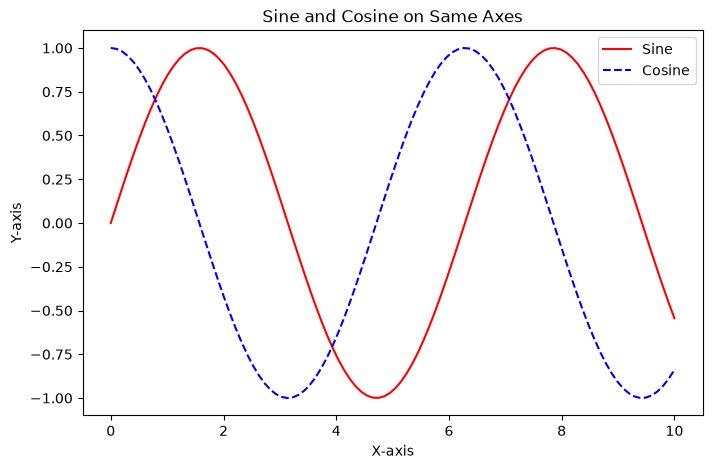

In [17]:
# test
# sample data
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# create a single figure
plt.figure(figsize=(8, 5))

# overlay multiple plots on the same figure
plt.plot(x, y1, 'r-', label='Sine')
plt.plot(x, y2, 'b--', label='Cosine')

# add labels and a legend
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Sine and Cosine on Same Axes')
plt.legend()

plt.show()

# fig, ax = plt.subplots(figsize=(12, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
